# TCDL Graphs

This Jupyter notebook contains the code to generate image and text summaries for the annual TCDL Usage Report. Currently, this report requires three sets of input files.

1. **Dataverse-users-{date}.xlsx - Dataverse-users-{date}.csv**: This file may either come in a CSV or an Excel format but should be converted to CSV for reading into the script (the string to identify the most recent version may need to be updated in the script). It contains a list of all users in TDR, including those not affiliated with any particular institution (the monthly institutional reports only contain affiliated users) and metadata about them (e.g., date of account creation, date of last API usage). It must be generated by an installation-level superuser (i.e. TDL).
2. **dataverse-reports-{date}**: This is a folder containing the most recent monthly reports for all TDR institutions (as well as UT Arlington, a former member). No additional processing is needed for these files; the script will load all of the files in and concatenate them together.
3. Outputs from the main assessment script that can be run by any regular TDR user. **{date}_all-institutions_all-datasets-combined-with-dataverses.csv** contains additional dataset-level metadata for published datasets. **{date}_all-institutions_all-dataverses.csv** contains additional collection-level metadata for published collections. **{date}_all-institutions_all-files-deduplicated-PUBLISHED.csv** contains additional file-level metadata for published files (though it normally excludes older versions / deleted versions of files that are not in the most recent published version).

## Additional notes

The graphs are labeled according to their current slide number as of the 2026 TCDL presentation; these will likely be shifted in the future. For many graphs, there are various alternative visualizations of the same data that were tested out; these are usually immediately recognizable because they do not use the same color palette as the final presentation version. These are included in the event that they are useful or preferred in the future.

## Workflow set-up

This codeblock contains the module import statements and loading of the requisite input dataframes.

In [ ]:
#| echo: false
#| warning: false
#| include: false

import ast
import json
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
import pandas as pd
from datetime import date, datetime
from matplotlib.patches import Circle
from matplotlib.gridspec import GridSpec
from utils import load_most_recent_file

# env file
with open('env.json', 'r') as file:
    env = json.load(file)

# Toggles
## Test environment (incomplete run, faster to complete)
test = env['TOGGLES']['test']
## Whether to exclue former/new members
current = env['TOGGLES']['current_members']
# ## Whether input is for all institutions or only one
# only_my_institution = env['TOGGLES']['only_my_institution']
# if only_my_institution:
#     institution_filename = env['INSTITUTION']['filename']
# else:
#     institution_filename = 'all-institutions'

# Dates, etc.
today = date.today()
today_pd = pd.Timestamp(today)
current_year = date.today().year
current_year_string = str(current_year)
first_of_current_year_string = current_year_string + '-01-01'
first_of_current_year = datetime.strptime(first_of_current_year_string, '%Y-%m-%d').date()
date_12_months_ago = today.replace(year=today.year - 1)
previous_tcdl = '2025-05-22'
previous_tcdl = pd.to_datetime(previous_tcdl)

# Graphical parameters
img_width = env['GRAPHS']['default_width']
img_height = env['GRAPHS']['default_height']
dpi = env['GRAPHS']['default_dpi']
format = env['GRAPHS']['default_extension']
title_font = env['GRAPHS']['default_title']
axis_font = env['GRAPHS']['default_axis_titles']
tick_font = env['GRAPHS']['default_axis_labels']
legend_font = env['GRAPHS']['default_legend']

# Lists and dictionaries
school_colors = env['SCHOOL_MAPS']['SCHOOL_COLORS']
school_names = env['SCHOOL_MAPS']['SCHOOL_NAMES']
display_names = env['SCHOOL_MAPS']['DISPLAY_NAMES']
current_members = env['SCHOOL_MAPS']['MEMBERS']['current_members']
current_members_and_none = env['SCHOOL_MAPS']['MEMBERS']['current_members_plus']

# Get directories
script_dir = os.getcwd()
if test:
    outputs_dir = os.path.join(script_dir, 'test/outputs')
else:
    outputs_dir = os.path.join(script_dir, 'outputs')

# Load most recent df of deposits
pattern = '_all-institutions_all-datasets-combined-with-dataverses.csv'
datasets = load_most_recent_file(outputs_dir, pattern)

pattern = '_all-institutions_all-dataverses.csv'
dataverses = load_most_recent_file(outputs_dir, pattern)

pattern = '_all-institutions_all-files-deduplicated-PUBLISHED.csv'
files = load_most_recent_file(outputs_dir, pattern)
files['category_mime_type'] = files['original_mime_type'].str.extract(r'(\w+)/')

pattern = 'Dataverse-users-2026'
users = load_most_recent_file(script_dir, pattern)

The most recent file '20260608_all-institutions_all-datasets-combined-with-dataverses.csv' has been loaded successfully.
The most recent file '20260608_all-institutions_all-dataverses.csv' has been loaded successfully.


c:\Users\bmg3525\OneDrive - The University of Texas at Austin\Documents\scripts\tdr-assessment-scripts\utils.py:362: DtypeWarning: Columns (3,25,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


The most recent file '20260608_all-institutions_all-files-deduplicated-PUBLISHED.csv' has been loaded successfully.
The most recent file 'Dataverse-users-20260428.xlsx - Dataverse-users-20260428.csv' has been loaded successfully.


## Preliminary data manipulation

These two codeblocks contain basic standardization and manipulation of the dataframes. They also define numerous lists or dictionaries that are called later in the script to standardize institutions' names and colors.

In [465]:
# Standardize order of size bin labels (for datasets)
bin_labels = [
    '0-10 kB',
    '10 kB-1 MB',
    '1-100 MB',
    '100 MB-1 GB',
    '1-10 GB',
    '10-15 GB',
    '15-20 GB',
    '20-25 GB',
    '25-30 GB',
    '30-40 GB',
    '40-50 GB',
    '>50 GB'
]

In [466]:
# All datasets

# Users
## Create full name column
users['Full Name'] = users['First Name'] + ' ' + users['Last Name']
## Remove TDL / test accounts
users_real = users[~users['Email'].str.contains('mailinator.com|tdl.student', na=False) & ~users['Full Name'].str.contains('Lauland|Smutniak|Ryan Steans|Mumma|Admin|Nicholas Woodward', na=False, case=False)]

# Filter to remove certain institutions (former/recent TDR members)
if current:
    # Filter to keep only current members and "No affiliation"
    files = files[files['institution'].isin(current_members_and_none)]
    datasets = datasets[datasets['institution_standardized'].isin(current_members_and_none)]
    dataverses = dataverses[dataverses['institution_standardized'].isin(current_members_and_none)]

# Files
## Drop any duplicate file types
files_dedup = files.drop_duplicates(subset=['doi', 'original_mime_type'])

# Standardizing institution affiliation
users_real['Affiliation_Standardized'] = users_real['Affiliation']
users_real['Affiliation_Standardized'] = users_real['Affiliation_Standardized'].replace(school_names)
users_real['Affiliation_Standardized'] = users_real['Affiliation_Standardized'].fillna('No affiliation')
## Replace affiliations not in the list with 'Other affiliation'
users_real['Affiliation_Standardized'] = users_real['Affiliation_Standardized'].apply(lambda x: x if x in current_members_and_none else 'Other affiliation')

## Remove sandbox datasets
datasets = datasets[~datasets['identifier'].str.startswith('FK2/')]
## Remove deaccessioned datasets
datasets_exist_df = datasets.dropna(subset=["createTime"])
## Remove draft datasets (but retain previously published datasets that are now in draft)
datasets_published_df = datasets_exist_df.dropna(subset=["publicationDate"])
## Get *only* unpublishe datasets
datasets_unpublished_df = datasets_exist_df[datasets_exist_df['publicationDate'].isna()]

# ########------------- TEMP
# datasets = datasets[~datasets['identifier_x'].str.startswith('FK2/')]
# datasets_exist_df = datasets.dropna(subset=["createTime_x"])
# datasets_published_df = datasets_exist_df.dropna(subset=["publicationDate_x"])
# ########------------- TEMP 


## Remove parent institution-level collections
### Remove rows where dataverse_name is blank AND dataverseType is ORGANIZATIONS_INSTITUTIONS AND released is Yes
dataverses_actual = dataverses[~(
    (dataverses['dataverse_name'].isna() | (dataverses['dataverse_name'].str.strip() == '')) &
    (dataverses['dataverseType'] == 'ORGANIZATIONS_INSTITUTIONS') &
    (dataverses['released'] == 'Yes')
)]
## Remove unpublished dataverses
dataverses_published = dataverses_actual[dataverses_actual["released"] == "Yes"]

print(f"Total number of datasets: {len(datasets)}\n")
print(f"Total number of existing (non-deaccessioned) datasets: {len(datasets_exist_df)}\n")
print(f"Total number of published datasets: {len(datasets_published_df)}\n")
print(f"Total number of unpublished datasets: {len(datasets_unpublished_df)}\n")
print(f"Total number of dataverses: {len(dataverses_actual)}\n")
print(f"Total number of published dataverses: {len(dataverses_published)}\n")

Total number of datasets: 3873

Total number of existing (non-deaccessioned) datasets: 3836

Total number of published datasets: 2974

Total number of unpublished datasets: 862

Total number of dataverses: 1331

Total number of published dataverses: 977



C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\1350048764.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  users_real['Affiliation_Standardized'] = users_real['Affiliation']
C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\1350048764.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  users_real['Affiliation_Standardized'] = users_real['Affiliation_Standardized'].replace(school_names)
C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\1350048764.py:23: SettingWithCopyWarning: 
A value is trying t

## Slide 5: TDR Users Over Time

    year_month_created  new_collections  total_collections
0              2017-01                2                  2
1              2017-02                2                  4
2              2017-03                3                  7
3              2017-04                3                 10
4              2017-05                1                 11
..                 ...              ...                ...
107            2026-01                9                624
108            2026-02               11                635
109            2026-03                8                643
110            2026-04                8                651
111            2026-05                1                652

[112 rows x 3 columns]


C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\795212875.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataverses_actual['creationDate'] = pd.to_datetime(dataverses_actual['creationDate'], errors='coerce')
C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\795212875.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  first_appearance['year_month_created'] = first_appearance['creationDate'].dt.to_period('M')
C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\795212875.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  first_appearance['year_month_created'] = first_appearance['created_final'].dt.to_period('M')
C:\Users\bmg3525\AppData\Local\T

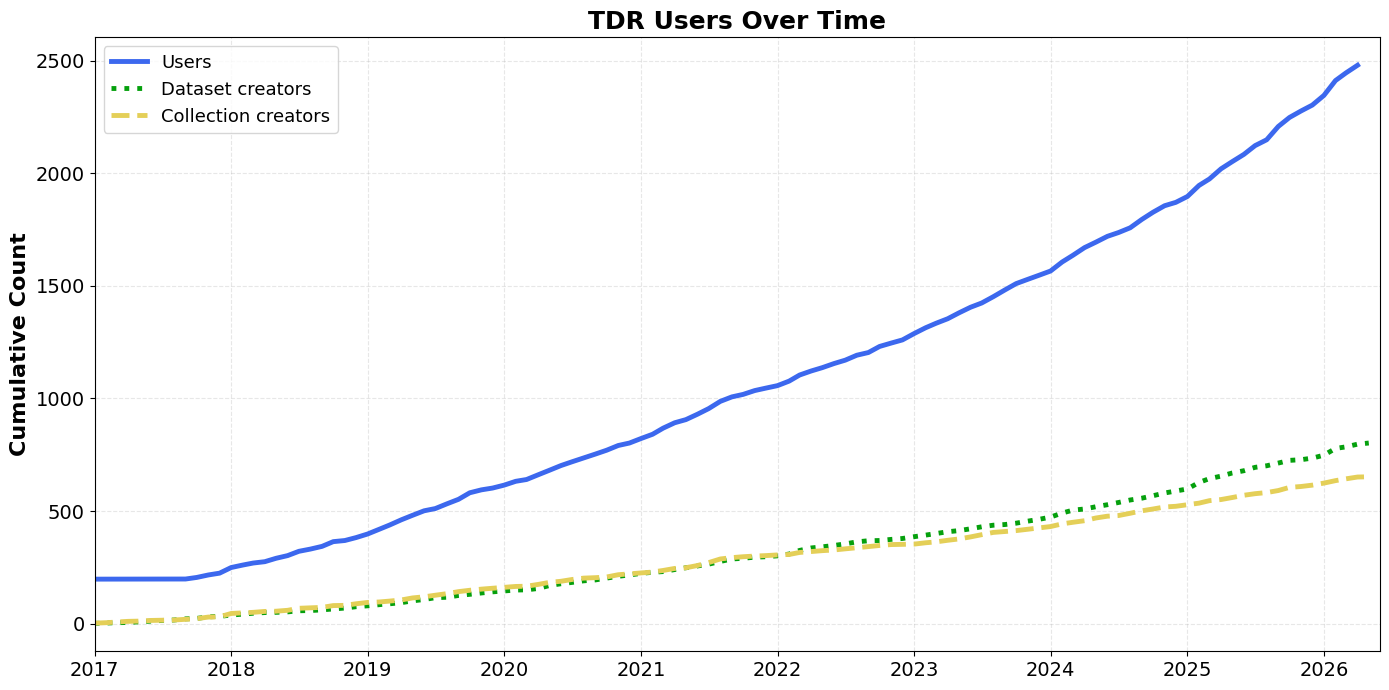

In [467]:
# To get summaries of dataset creators and collection creators
## Collections
### For each unique contactIdentifier, get the earliest date
#### Convert to datetime, coercing errors to NaT
dataverses_actual['creationDate'] = pd.to_datetime(dataverses_actual['creationDate'], errors='coerce')
first_appearance = dataverses_actual.groupby('contactIdentifier')['creationDate'].min().reset_index()
first_appearance['year_month_created'] = first_appearance['creationDate'].dt.to_period('M')

### Count unique contacts per month (cumulative)
monthly_counts_dataverses = first_appearance.groupby('year_month_created').size().reset_index(name='new_collections')
monthly_counts_dataverses['total_collections'] = monthly_counts_dataverses['new_collections'].cumsum()

print(monthly_counts_dataverses)

## Datasets
### For each unique contactIdentifier, get the earliest date
datasets['created_final'] = pd.to_datetime(datasets['created_final'], errors='coerce')
first_appearance = datasets.groupby('dataset_depositor')['created_final'].min().reset_index()
first_appearance['year_month_created'] = first_appearance['created_final'].dt.to_period('M')
### Count unique contacts per month (cumulative)
monthly_counts_datasets = first_appearance.groupby('year_month_created').size().reset_index(name='new_datasets')
monthly_counts_datasets['total_datasets'] = monthly_counts_datasets['new_datasets'].cumsum()

### unique deposits - PUBLISHED
monthly_counts = datasets.groupby('year_month_published').size()
cumulative_counts = monthly_counts.cumsum()

# Convert index to datetime
cumulative_counts.index = pd.to_datetime(cumulative_counts.index)

dataset_publish_counts = cumulative_counts.reset_index()
dataset_publish_counts.columns = ['year_month', 'total']
dataset_publish_counts['category'] = 'Published'

### unique deposits - CREATED
monthly_counts = datasets.groupby('year_month_created').size()
cumulative_counts = monthly_counts.cumsum()

# Convert index to datetime
cumulative_counts.index = pd.to_datetime(cumulative_counts.index)

dataset_create_counts = cumulative_counts.reset_index()
dataset_create_counts.columns = ['year_month', 'total']
dataset_create_counts['category'] = 'Created'

### Concatenate
dataset_concat = pd.concat([dataset_publish_counts, dataset_create_counts], ignore_index=True)



users_plot = users_real.copy()
## Date conversions
users_plot['Last Login'] = pd.to_datetime(users_plot['Last Login']).dt.date
users_plot['Created'] = pd.to_datetime(users_plot['Created'])
### Extract year-month
users_plot['year_month_created'] = users_plot['Created'].dt.to_period('M')
### Count records per month
monthly_counts = users_plot.groupby('year_month_created').size()
### Convert to cumulative sum
cumulative_counts = monthly_counts.cumsum()
### Convert index to timestamp for plotting
cumulative_counts.index = cumulative_counts.index.to_timestamp()
### Format df
users_summary = cumulative_counts.reset_index()
users_summary.columns = ['year_month_created', 'total']
users_summary['category'] = 'Users'

# Combine all user dfs
## Datasets
datasets_summary = monthly_counts_datasets.copy()
datasets_summary = datasets_summary[['year_month_created', 'total_datasets']]
datasets_summary = datasets_summary[['year_month_created', 'total_datasets']].reset_index(drop=True)
datasets_summary.columns = ['year_month_created', 'total']
datasets_summary['category'] = 'Dataset creators'
datasets_summary['year_month_created'] = datasets_summary['year_month_created'].dt.to_timestamp()

## Collections
dataverses_summary = monthly_counts_dataverses.copy()
dataverses_summary = dataverses_summary[['year_month_created', 'total_collections']]
dataverses_summary.columns = ['year_month_created', 'total']
dataverses_summary['category'] = 'Collection creators'
dataverses_summary['year_month_created'] = dataverses_summary['year_month_created'].dt.to_timestamp()

combined_summary = pd.concat([users_summary, datasets_summary, dataverses_summary], ignore_index=True)

### Ensure year_month is datetime for plotting
combined_summary['year_month_created'] = pd.to_datetime(combined_summary['year_month_created'])

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))

# Define colors and line styles for each category
styles = {
    'Users': {'color': "#3c68ee", 'linestyle': 'solid', 'linewidth': 3.5},
    'Dataset creators': {'color': "#05A00D", 'linestyle': 'dotted', 'linewidth': 3.5},
    'Collection creators': {'color': "#E4CF58", 'linestyle': 'dashed', 'linewidth': 3.5}
}

# Plot each category
for category in combined_summary['category'].unique():
    data = combined_summary[combined_summary['category'] == category]
    style = styles[category]
    
    ax.plot(data['year_month_created'], data['total'], 
            label=category,
            color=style['color'], 
            linestyle=style['linestyle'],
            linewidth=style['linewidth'])

# Labels, etc.
ax.set_xlabel('', fontsize=axis_font, fontweight='bold')
ax.set_xlim(pd.Timestamp('2017-01-01'), pd.Timestamp('2026-05-31'))
ax.set_ylabel('Cumulative Count', fontsize=axis_font, fontweight='bold')
ax.set_title('TDR Users Over Time', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(True, alpha=0.3, linestyle='--')

# Add legend
ax.legend(fontsize=legend_font, loc='upper left')

plt.tight_layout()
plt.show()

## Slide 6: TDR Users by Last Login

C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\215757709.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  users_plot['Last Login'] = pd.to_datetime(users_plot['Last Login'])


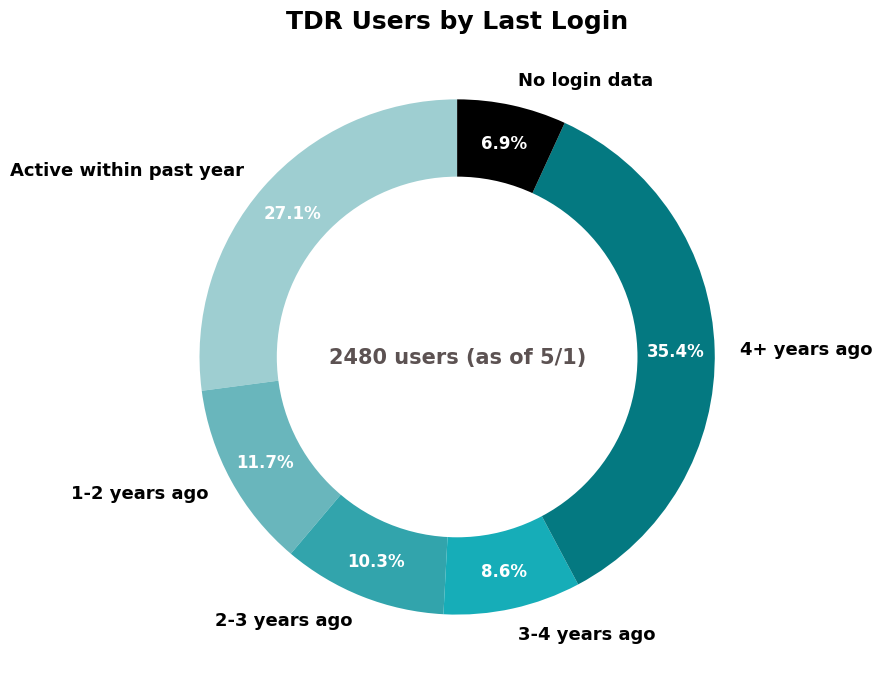

In [468]:
#| echo: false
#| warning: false

users_plot = users_real.copy()

# Convert 'Last Login' to datetime
## This is slightly different than the previous date conversion for this variable
users_plot['Last Login'] = pd.to_datetime(users_plot['Last Login'])
## Calculate days since last login
users_plot['Days Since Login'] = (today_pd - users_plot['Last Login']).dt.days

# Create bins for last login
def bin_last_login(days):
    if pd.isna(days):
        return 'No login data'
    elif days <= 365:
        return 'Active within past year'
    elif days <= 730:
        return '1-2 years ago'
    elif days <= 1095:
        return '2-3 years ago'
    elif days <= 1460:
        return '3-4 years ago'
    else:
        return '4+ years ago'
users_plot['Login Bin'] = users_plot['Days Since Login'].apply(bin_last_login)

## Count by bin
login_counts = users_plot['Login Bin'].value_counts()
## Define order for plotting
category_order = [
    'Active within past year',
    '1-2 years ago',
    '2-3 years ago',
    '3-4 years ago',
    '4+ years ago',
    'No login data'
]
## Reorder the series
login_counts = login_counts.reindex(category_order)

###########################################
###             PLOT                    ###
###########################################
fig, ax = plt.subplots(figsize=(10, img_height))

# Define colors for each bin
colors = ["#9eced1", "#69b6bc", "#32a4ac", "#16adb8", "#047981", "#000000"]

# Create donut chart
wedges, texts, autotexts = ax.pie(
    login_counts.values,
    labels=login_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 13},
    pctdistance=0.85
)
for text in texts:
    text.set_fontweight('bold')
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)
    autotext.set_color('white')

# Create the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)
# Create text to go in the donut hole
total_count = len(users_plot)
ax.text(0, 0, f'{total_count} users (as of 5/1)', ha='center', va='center', 
        fontsize=15, fontweight='bold', color="#5C5252")

# Labels, etc.
ax.set_title('TDR Users by Last Login', fontsize=title_font, fontweight='bold', pad=5)

plt.tight_layout()
plt.show()

## Slilde 7: TDR Users by Number of Deposits

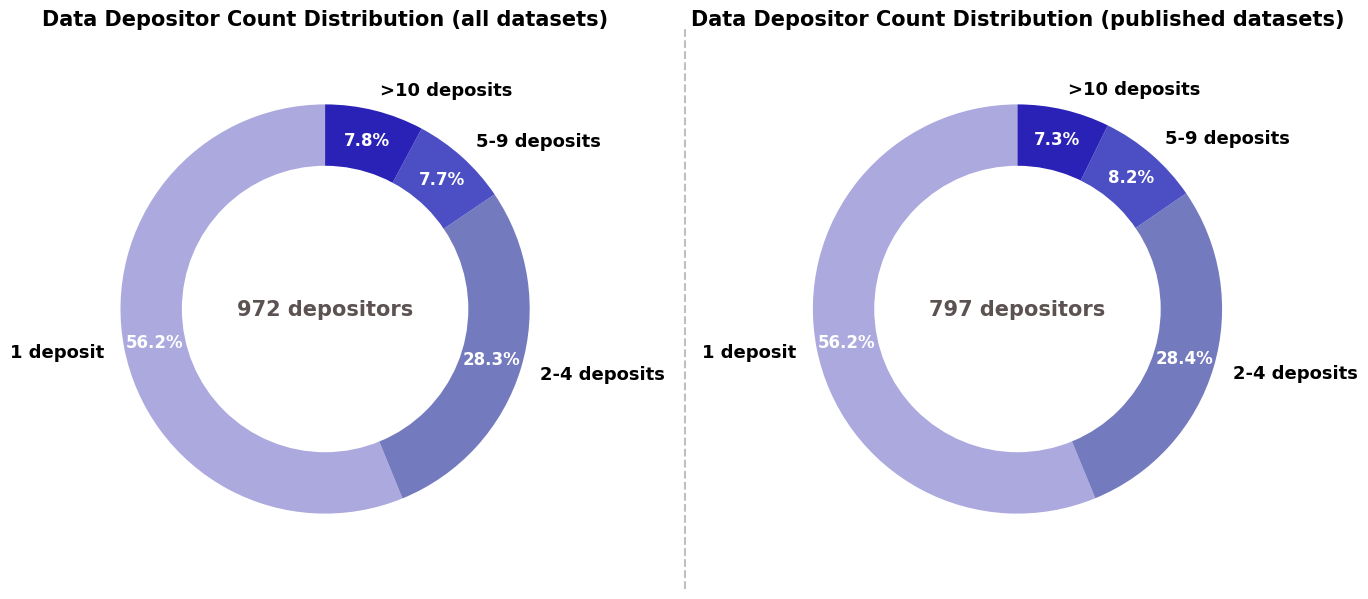

In [469]:
# Summarize counts for published deposits
datasets_plot = datasets_published_df.copy()
depositor_count_pub = datasets_plot['dataset_depositor'].value_counts().reset_index()

def bin_deposits(count):
    if count ==1:
        return '1 deposit'
    elif count >1 and count <5:
        return '2-4 deposits'
    elif count >4 and count < 10:
        return '5-9 deposits'
    else:
        return '>10 deposits'

depositor_count_pub['Deposit Bin'] = depositor_count_pub['count'].apply(bin_deposits)
depositor_bin_count = depositor_count_pub['Deposit Bin'].value_counts()

category_order = [
    '1 deposit',
    '2-4 deposits',
    '5-9 deposits',
    '>10 deposits'
]
depositor_bin_count = depositor_bin_count.reindex(category_order)

# Summarize counts for all deposits
datasets_plot = datasets.copy()
depositor_count_all = datasets_plot['depositor'].value_counts().reset_index()
depositor_count_all['Deposit Bin'] = depositor_count_all['count'].apply(bin_deposits)
depositor_count_all_count = depositor_count_all['Deposit Bin'].value_counts()
depositor_count_all_count = depositor_count_all_count.reindex(category_order)

###########################################
###             PLOT                    ###
###########################################
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(img_width, img_height))

# All depositors
colors = ["#aca9df", "#747abe", "#4c4ec4", "#2a22b6"]

wedges, texts, autotexts = ax1.pie(
    depositor_bin_count.values,
    labels=depositor_bin_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 13},
    pctdistance=0.85
)
for text in texts:
    text.set_fontweight('bold')
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)
    autotext.set_color('white')

# Create the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax1.add_artist(centre_circle)
# Add text in the donut hole
total_count = len(depositor_count_pub)
ax1.text(0, 0, f'{total_count} depositors', ha='center', va='center', 
        fontsize=15, fontweight='bold', color="#5C5252")

# Labels, etc.
ax1.set_title('Data Depositor Count Distribution (published datasets)', fontsize=15, fontweight='bold', pad=20)



# Published datasets
wedges, texts, autotexts = ax2.pie(
    depositor_count_all_count.values,
    labels=depositor_count_all_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 13},
    pctdistance=0.85
)

for text in texts:
    text.set_fontweight('bold')
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)
    autotext.set_color('white')

# Create the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax2.add_artist(centre_circle)
# Add text in the donut hole
total_count = len(depositor_count_all)
ax2.text(0, 0, f'{total_count} depositors', ha='center', va='center', 
        fontsize=15, fontweight='bold', color="#5C5252")

# Labels, etc.
ax2.set_title('Data Depositor Count Distribution (all datasets)', fontsize=15, fontweight='bold', pad=20)

# Add divider line and space
plt.subplots_adjust(wspace=1)
fig.add_artist(plt.Line2D([0.5, 0.5], [0.1, 0.9], 
                          transform=fig.transFigure, 
                          color='gray', 
                          linewidth=1.5, 
                          linestyle='--',
                          alpha=0.5))

plt.tight_layout()
plt.show()

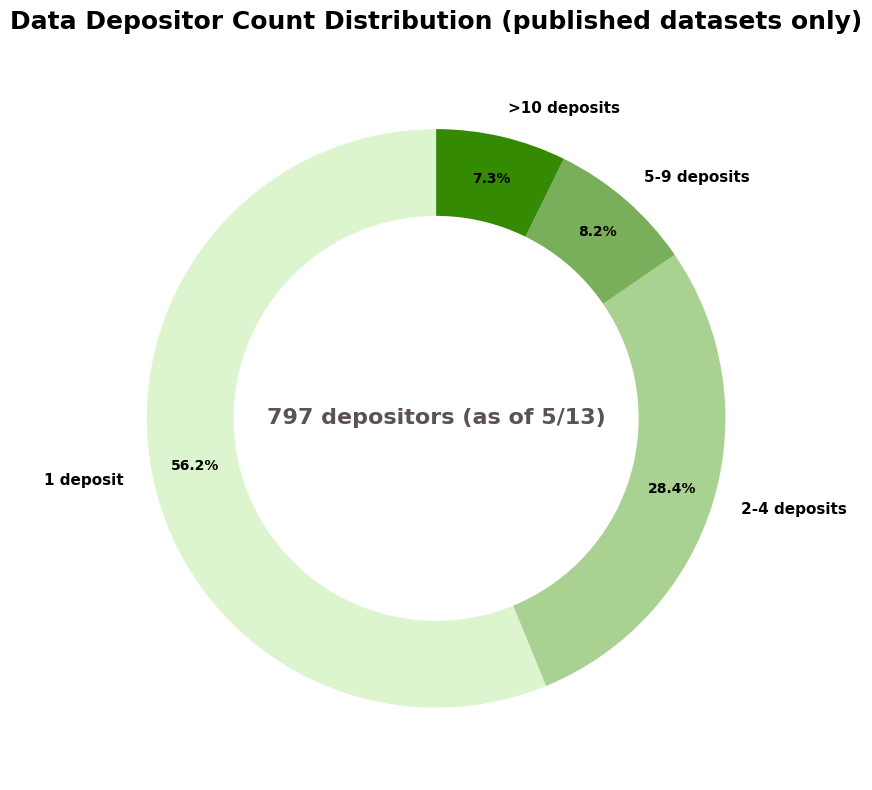

In [470]:
fig, ax = plt.subplots(figsize=(10, 8))

# Define colors for each bin
colors = ["#dcf5ce", "#a9d192", "#79ae5a", "#358a04"]

# Create donut chart
wedges, texts, autotexts = ax.pie(
    depositor_bin_count.values,
    labels=depositor_bin_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11},
    pctdistance=0.85
)

for text in texts:
    text.set_fontweight('bold')
    text.set_fontsize(11)

# Control percentage weight independently
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)
    autotext.set_color('black')

# Create the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

total_count = len(depositor_count_pub)
ax.text(0, 0, f'{total_count} depositors (as of 5/13)', ha='center', va='center', 
        fontsize=16, fontweight='bold', color="#5C5252")

# Customize the plot
ax.set_title('Data Depositor Count Distribution (published datasets only)', fontsize=title_font, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

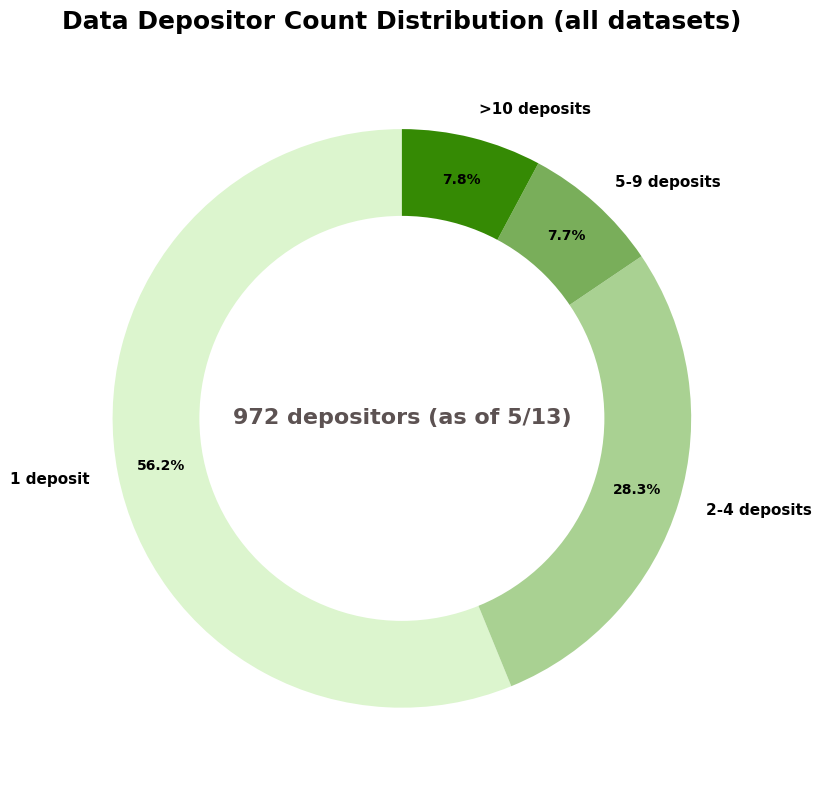

In [471]:
fig, ax = plt.subplots(figsize=(10, 8))

# Define colors for each bin
colors = ["#dcf5ce", "#a9d192", "#79ae5a", "#358a04"]

# Create donut chart
wedges, texts, autotexts = ax.pie(
    depositor_count_all_count.values,
    labels=depositor_count_all_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11},
    pctdistance=0.85
)

for text in texts:
    text.set_fontweight('bold')
    text.set_fontsize(11)

# Control percentage weight independently
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)
    autotext.set_color('black')

# Create the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

total_count = len(depositor_count_all)
ax.text(0, 0, f'{total_count} depositors (as of 5/13)', ha='center', va='center', 
        fontsize=16, fontweight='bold', color="#5C5252")

# Labels, etc.
ax.set_title('Data Depositor Count Distribution (all datasets)', fontsize=title_font, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## Slide 8: Users by Institution

C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\1096208810.py:87: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=colors[cat], edgecolor='black', linewidth=1.2, alpha=0.8) for cat in categories]


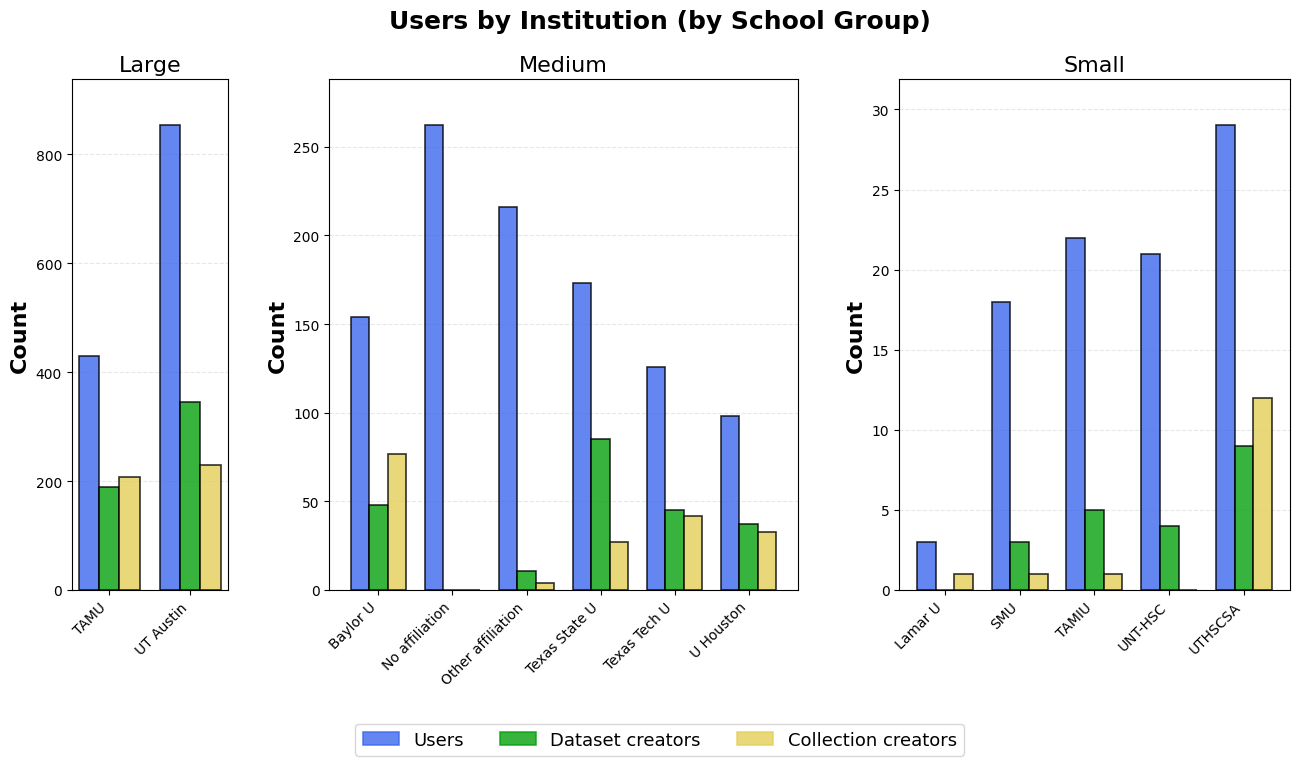

In [472]:
# Group by institution and count unique users
users_by_institution = users_real.groupby('Affiliation_Standardized').size().reset_index(name='total')
users_by_institution.rename(columns={'Affiliation_Standardized': 'institution'}, inplace=True)
users_by_institution['category'] = 'Users'

# Group by institution and count unique contactIdentifiers (contacts/depositors)
datasets_by_institution = datasets.groupby('institution_standardized')['dataset_depositor'].nunique().reset_index(name='total')
datasets_by_institution.rename(columns={'institution_standardized': 'institution'}, inplace=True)
datasets_by_institution['category'] = 'Dataset creators'

# Group by institution and count unique dataverses
dataverses_by_institution = dataverses_actual.groupby('institution_standardized')['contactIdentifier'].nunique().reset_index(name='total')
dataverses_by_institution.rename(columns={'institution_standardized': 'institution'}, inplace=True)
dataverses_by_institution['category'] = 'Collection creators'

# Combine all three
combined_by_institution = pd.concat([users_by_institution, datasets_by_institution, dataverses_by_institution], ignore_index=True)

school_groups = {
    'Large': ['UT Austin', 'TAMU'],
    'Medium': ['U Houston', 'Baylor U', 'Texas Tech U', 'Texas State U', 'No affiliation', 'Other affiliation'],
    'Small': ['TAMIU', 'UNT-HSC', 'UTHSCSA', 'Lamar U', 'SMU']
}

# Condition subplot width based on number of schools
## Will ensure all bars are the same width regardless of how many are in a subplot
width_ratios = [len(schools) for schools in school_groups.values()]

###########################################
###             PLOT                    ###
###########################################

fig = plt.figure(figsize=(img_width, img_height))
gs = GridSpec(1, 3, width_ratios=width_ratios, wspace=0.3)

bar_width = 0.25
categories = ['Users', 'Dataset creators', 'Collection creators']
colors = {
    'Users': '#3c68ee',
    'Dataset creators': '#05A00D',
    'Collection creators': '#E4CF58'
}

for idx, (group_name, schools) in enumerate(school_groups.items()):
    ax = fig.add_subplot(gs[0, idx])
    
    # Filter data for this group
    group_data = combined_by_institution[combined_by_institution['institution'].isin(schools)]
    institutions_in_group = group_data['institution'].unique()
    
    x_pos = np.arange(len(institutions_in_group))
    # Increase y-axis lim above max bar height
    y_max = group_data['total'].max()
    ax.set_ylim(0, y_max*1.1)

    # Plot grouped bars for each category
    for i, category in enumerate(categories):
        category_data = group_data[group_data['category'] == category]
        
        # Create a mapping of institution to total for this category
        values = [category_data[category_data['institution'] == inst]['total'].values[0] 
                  if inst in category_data['institution'].values else 0 
                  for inst in institutions_in_group]
        
        ax.bar(x_pos + (i - 1) * bar_width, values, bar_width, 
               label=category, color=colors[category], edgecolor='black', linewidth=1.2, alpha=0.8)
        
        # # Add value labels on top of bars
        # for j, val in enumerate(values):
        #     if val > 0:
        #         ax.text(j + (i - 1) * bar_width, val + (y_max * 0.01), f'{int(val)}', 
        #                 ha='center', va='bottom', fontsize=10)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(institutions_in_group, rotation=45, ha='right')
    ax.set_ylabel('Count', fontsize=axis_font, fontweight='bold')
    ax.set_xlabel('', fontsize=axis_font, fontweight='bold')
    ax.set_title(group_name, fontsize=16) # This is 'Large', 'Medium', 'Small', not the entire fig title
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.legend(fontsize=legend_font, loc='upper right')

# Remove individual legends and create a single shared legend
for ax in fig.get_axes():
    ax.get_legend().remove()
## Create shared legend below the plots
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[cat], edgecolor='black', linewidth=1.2, alpha=0.8) for cat in categories]
fig.legend(handles, categories, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=legend_font, frameon=True)

fig.suptitle('Users by Institution (by School Group)', fontsize=title_font, fontweight='bold', y=0.98)
plt.subplots_adjust(left=0.08, right=0.95, top=0.88, bottom=0.15)
plt.show()

## Slide 9: API Usage

Total number of API users: 525
.
Total number of API users without an affiliation: 88
.
Total number of API users without a confirmed email: 92
.
Total number of API users without a confirmed email: 70
.


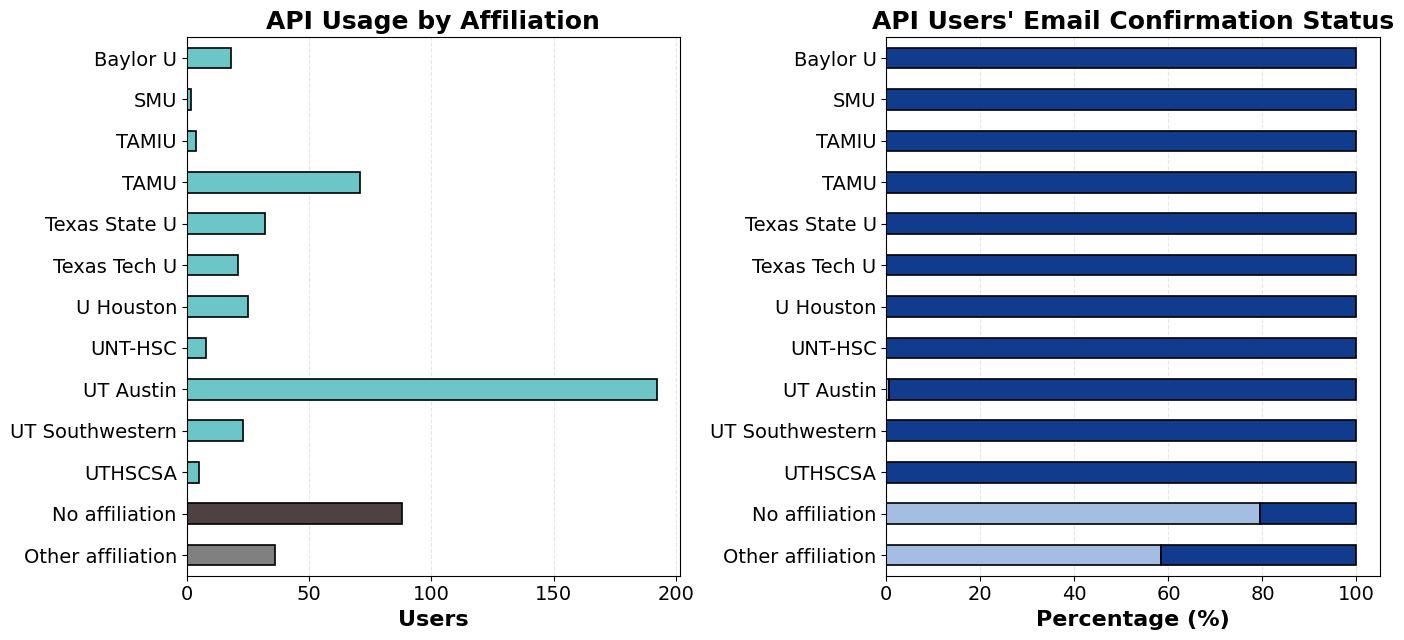

In [473]:
api_users = users_real[users_real['Last API Use'].notnull()]
print(f'Total number of API users: {len(api_users)}\n.')
api_users_no_affil = api_users[api_users['Affiliation'].isnull()]
print(f'Total number of API users without an affiliation: {len(api_users_no_affil)}\n.')
api_users_no_email = api_users[api_users['Email Confirmed'].isnull()]
print(f'Total number of API users without a confirmed email: {len(api_users_no_email)}\n.')
api_users_suspicious = api_users[(api_users['Email Confirmed'].isnull()) & (api_users['Affiliation'].isnull())]
print(f'Total number of API users without a confirmed email: {len(api_users_suspicious)}\n.')

api_users_plot = api_users.copy()
# Replace affiliations not in the list with 'Other affiliation'
api_users_plot['Affiliation_Standardized'] = api_users_plot['Affiliation_Standardized'].apply(
    lambda x: x if x in current_members_and_none else 'Other affiliation'
)

# Summarize API usage by institution
api_use_by_affiliation = api_users_plot['Last API Use'].groupby(api_users_plot['Affiliation_Standardized']).count()
current_members_sorted = sorted(current_members, reverse=True)
other = ['Other affiliation', 'No affiliation']
desired_order = other + current_members_sorted
api_use_by_affiliation = api_use_by_affiliation.reindex(desired_order)
api_use_by_affiliation = api_use_by_affiliation[api_use_by_affiliation > 0]

# Summarize API users by email confirmation status
api_users_plot['Email_Confirmed'] = api_users_plot['Email Confirmed'].notna() & (api_users_plot['Email Confirmed'] != '')
email_by_affiliation = api_users_plot.groupby(['Affiliation_Standardized', 'Email_Confirmed']).size().unstack()
email_by_affiliation_pct = email_by_affiliation.div(email_by_affiliation.sum(axis=1), axis=0) * 100
email_by_affiliation_pct = email_by_affiliation_pct.reindex(desired_order)
email_by_affiliation_pct = email_by_affiliation_pct.dropna(how='all')

###########################################
###             PLOT                    ###
###########################################

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(img_width, 6.5))

# LEFT: Usage by institution
## Set one color for all TDR members
chart_colors = {inst: '#6cc6c8' for inst in current_members}
chart_colors.update({
    'Other affiliation': '#808080',
    'No affiliation': '#4D4141'
})
colors = [chart_colors.get(inst, '#6cc6c8') for inst in api_use_by_affiliation.index]

api_use_by_affiliation.plot(kind='barh', ax=ax1, color=colors, edgecolor='black', linewidth=1.2)

## Labels, etc.
ax1.set_xlabel('Users', fontsize=axis_font, fontweight='bold')
ax1.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax1.set_title('API Usage by Affiliation', fontsize=title_font, fontweight='bold')
ax1.tick_params(labelsize=tick_font)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# RIGHT: API usage by email confirmation 
colors_email = ["#a4bde2", "#113c8d"]
email_by_affiliation_pct.plot(kind='barh', stacked=True, ax=ax2, color=colors_email, edgecolor='black', linewidth=1.2)

## Labels, etc.
ax2.set_xlabel('Percentage (%)', fontsize=axis_font, fontweight='bold')
ax2.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax2.set_title("API Users' Email Confirmation Status", fontsize=title_font, fontweight='bold')
ax2.tick_params(labelsize=tick_font)
ax2.legend().remove()
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Slide 11: Cumulative Storage Size

4.0298822556589275
11.327992511142593
year_month_created
2017-04    1.734843e-07
2017-05    8.839961e-07
2017-09    1.623457e-05
2017-10    1.492989e-03
2017-11    1.493278e-03
               ...     
2026-01    2.618614e+00
2026-02    3.525745e+00
2026-03    4.006545e+00
2026-04    4.014221e+00
2026-05    4.029882e+00
Name: size_tb, Length: 103, dtype: float64
YearMonth
2017-01-01    0.000792
2017-03-01    0.000803
2017-04-01    0.002461
2017-05-01    0.002524
2017-06-01    0.026909
                ...   
2026-02-01    6.972418
2026-03-01    7.635421
2026-04-01    7.715233
2026-05-01    8.047617
2026-06-01    8.047618
Name: size_tb, Length: 113, dtype: float64


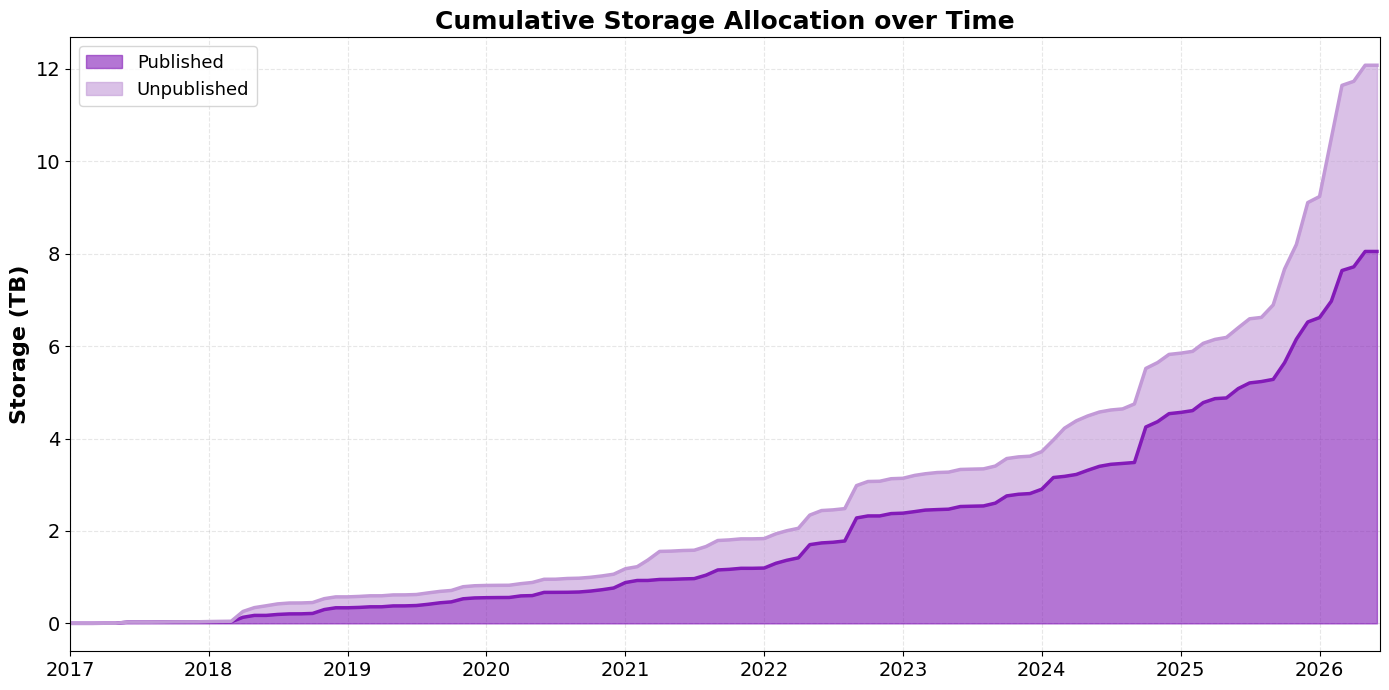

In [474]:
# Get data on unpublished datasets from TDL dump
datasets_copy = datasets.copy()
mask = datasets_copy['publicationDate'].isna() | (datasets_copy['publicationDate'].astype(str).str.strip() == '')
datasets_copy = datasets_copy[mask]
datasets_copy['size_tb'] = datasets_copy['contentSize_MB'] / (1024 **2)

total_tb = datasets_copy['contentSize_MB'].sum() / (1024 ** 2)
print(total_tb)
total_tb = datasets['contentSize_MB'].sum() / (1024 ** 2)
print(total_tb)

monthly_counts_datasets = datasets_copy.groupby('year_month_created')['size_tb'].sum()
cumulative_filesize_datasets = monthly_counts_datasets.cumsum()
print(cumulative_filesize_datasets)
## Convert period index to timestamp for plotting
# cumulative_filesize_datasets.index = cumulative_filesize_datasets.index.to_timestamp()

# Get data on published datasets' from file-level metadata
files_copy = files.copy()
files_copy['file_creation_date'] = pd.to_datetime(files_copy['file_creation_date'])
files_copy['size_gb'] = files_copy['file_size'] / (1024**3)
files_copy['size_tb'] = files_copy['size_gb'] / 1024
files_copy['YearMonth'] = files_copy['file_creation_date'].dt.to_period('M')
monthly_counts = files_copy.groupby('YearMonth')['size_tb'].sum()
cumulative_filesize = monthly_counts.cumsum()
## Convert period index to timestamp for plotting
cumulative_filesize.index = cumulative_filesize.index.to_timestamp()
print(cumulative_filesize)

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))

# Align the indices to ensure both series have the same dates
cumulative_filesize.index = pd.to_datetime(cumulative_filesize.index).to_period('M').to_timestamp()
cumulative_filesize_datasets.index = pd.to_datetime(cumulative_filesize_datasets.index).to_period('M').to_timestamp()

all_dates = cumulative_filesize.index.union(cumulative_filesize_datasets.index)
files_aligned = cumulative_filesize.reindex(all_dates, method='ffill').fillna(0)
datasets_aligned = cumulative_filesize_datasets.reindex(all_dates, method='ffill').fillna(0)

# Plot stacked area chart
ax.fill_between(files_aligned.index, 0, files_aligned.values, 
                alpha=0.6, color="#831ab8", label='Published')
ax.fill_between(datasets_aligned.index, files_aligned.values, 
                files_aligned.values + datasets_aligned.values, 
                alpha=0.6, color="#c299d7", label='Unpublished')

# Plot the lines on top
ax.plot(files_aligned.index, files_aligned.values, 
        color="#831ab8", linewidth=2.5)
ax.plot(datasets_aligned.index, files_aligned.values + datasets_aligned.values, 
        color="#c299d7", linewidth=2.5)

# Customize the plot
ax.set_xlabel('', fontsize=axis_font, fontweight='bold')
ax.set_xlim(pd.Timestamp('2017-01-01'), today)
ax.set_ylabel('Storage (TB)', fontsize=axis_font, fontweight='bold')
ax.set_title('Cumulative Storage Allocation over Time', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=legend_font, loc='upper left')

plt.tight_layout()
plt.show()

## Slide 12: Storage Allocation by Institution

                          unpublished_size  published_size    total_size
institution_standardized                                                
UTHSCSA                       7.663810e+05    8.880422e+08  8.888086e+08
UT Southwestern               1.409297e+12    1.097083e+12  2.506379e+12
UT Austin                     8.433378e+11    3.738959e+12  4.582297e+12
UNT-HSC                       1.007900e+07    2.392089e+10  2.393097e+10
U Houston                     1.014204e+11    3.617572e+11  4.631776e+11
Texas Tech U                  1.348954e+10    4.169110e+10  5.518064e+10
Texas State U                 1.454081e+12    2.073532e+11  1.661435e+12
TAMU Galveston                5.998753e+06    5.877683e+09  5.883682e+09
TAMU                          4.299581e+11    1.869651e+12  2.299609e+12
TAMIU                         4.523244e+10    3.037237e+11  3.489562e+11
SMU                           6.975513e+08    8.880693e+10  8.950448e+10
Other affiliation             0.000000e+00    3.199

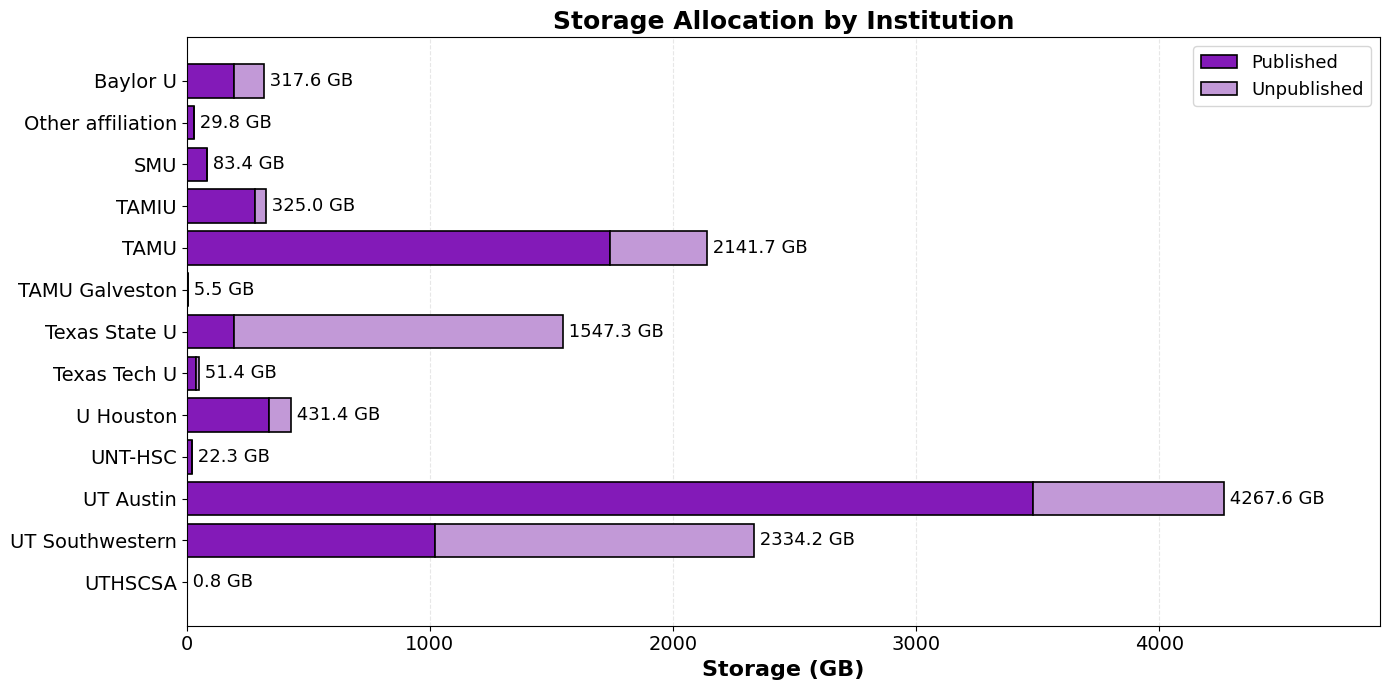

In [475]:
# Get published datasets total size (in bytes)
datasets_published = datasets_published_df.copy()
published_size = datasets_published.groupby('institution_standardized')['dataset_size'].sum().reset_index(name='published_size')

# Get all datasets total size (in MB, convert to bytes for consistency)
datasets_unpublished = datasets_unpublished_df.copy()
unpublished_size = datasets_unpublished.groupby('institution_standardized')['contentSize_MB'].sum().reset_index(name='unpublished_size')
unpublished_size['unpublished_size'] = unpublished_size['unpublished_size'] * (1024**2)

# Merge on institution
merged = unpublished_size.merge(published_size, on='institution_standardized', how='outer').fillna(0)
merged = merged[merged['institution_standardized'] != 0]
merged = merged.set_index('institution_standardized')

# Calculate total size
merged['total_size'] = merged['unpublished_size'] + merged['published_size']

merged = merged.sort_index(ascending=False)

print(merged)

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))
y_pos = np.arange(len(merged))

# Stacked bars: published on bottom, unpublished on top
ax.barh(y_pos, merged['published_size'].values / (1024**3), 
        label='Published', color='#831ab8', edgecolor='black', linewidth=1.2)
ax.barh(y_pos, merged['unpublished_size'].values / (1024**3), 
        left=merged['published_size'].values / (1024**3),
        label='Unpublished', color='#c299d7', edgecolor='black', linewidth=1.2)

# Add collective size labels
for i, total in enumerate(merged['total_size'].values):
    if total > 0:
        size_gb = total / (1024**3)
        ax.text(size_gb, i, f' {size_gb:.1f} GB', ha='left', va='center', fontsize=13)

# Labels, etc.
ax.set_yticks(y_pos)
ax.set_yticklabels(merged.index)
ax.set_xlabel('Storage (GB)', fontsize=axis_font, fontweight='bold')
ax.set_ylabel('', fontsize=16, fontweight='bold')
ax.set_title('Storage Allocation by Institution', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=legend_font, loc='upper right')

# Add padding to x-axis to accommodate labels
x_max = merged['total_size'].max() / (1024**3)
ax.set_xlim(0, x_max * 1.15)

plt.tight_layout()
plt.show()

## Slide 13: Dataset Count and Storage Size by Dataset Size Bin


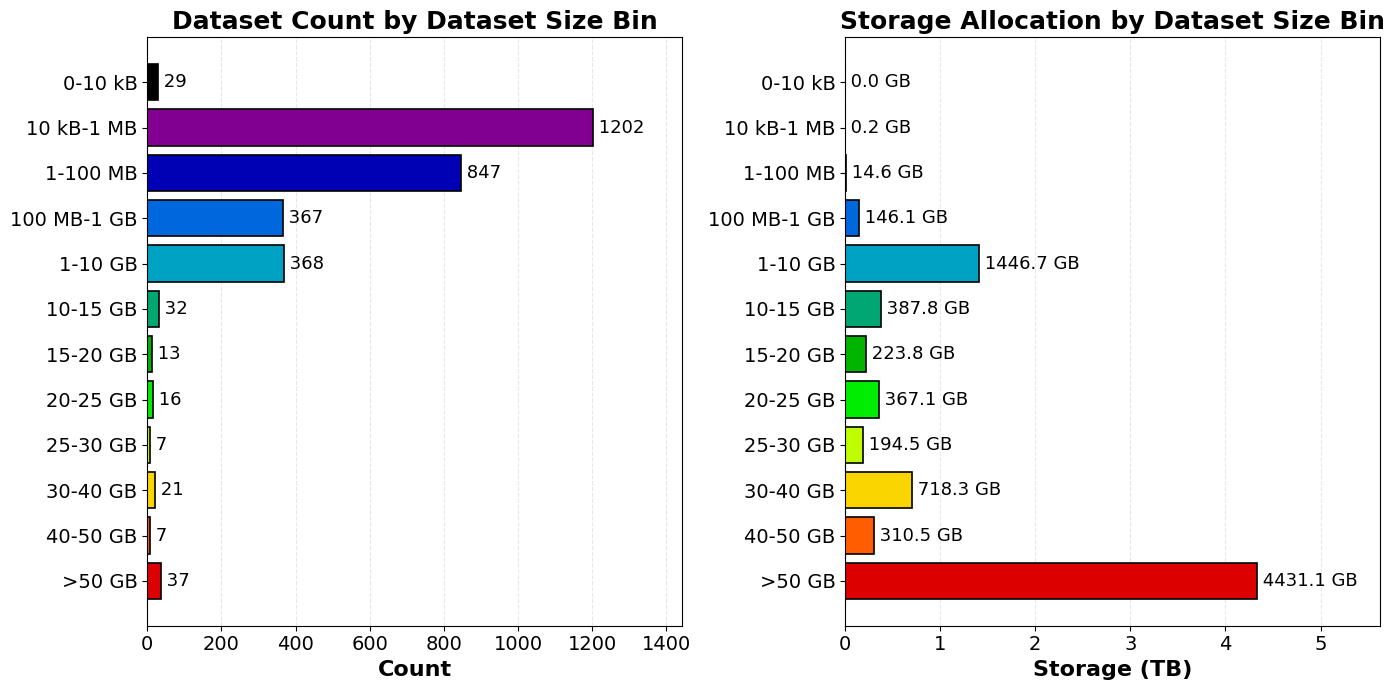

In [476]:
# Counting datasets in each size bin
datasets_plot = datasets.copy()
datasets_by_size_tdr = datasets_plot.groupby(['dataset_size_bin']).size().reset_index(name='count')
datasets_by_size_tdr = datasets_by_size_tdr.set_index('dataset_size_bin')
datasets_by_size_tdr = datasets_by_size_tdr.reindex(bin_labels[::-1], fill_value=0)

# Counting total storage size in each size bin
datasets_plot = datasets.copy()
datasets_size_sum = datasets_plot.groupby('dataset_size_bin')['dataset_size'].sum().reset_index(name='total_size')
datasets_size_sum = datasets_size_sum.set_index('dataset_size_bin')
datasets_size_sum = datasets_size_sum.reindex(bin_labels[::-1], fill_value=0)
datasets_size_sum['total_size_tb'] = datasets_size_sum['total_size'] / (1024**4)


datasets_by_size_school = datasets_plot.groupby(['institution_standardized', 'dataset_size_bin']).size().reset_index(name='count')
pivot_df_count = datasets_by_size_school.pivot(index='institution_standardized', columns='dataset_size_bin', values='count').fillna(0)
pivot_df_count = pivot_df_count.reindex(columns=bin_labels, fill_value=0)
pivot_pct_count = pivot_df_count.div(pivot_df_count.sum(axis=1), axis=0) * 100
all_data_count = pivot_pct_count.sort_index(ascending=False)

datasets_by_size_school_sum = datasets_plot.groupby(['institution_standardized', 'dataset_size_bin']).agg(
    total_size=('dataset_size', 'sum')
).reset_index()
pivot_df_size = datasets_by_size_school_sum.pivot(index='institution_standardized', columns='dataset_size_bin', values='total_size').fillna(0)
pivot_df_size = pivot_df_size.reindex(columns=bin_labels, fill_value=0)
pivot_pct_size = pivot_df_size.div(pivot_df_size.sum(axis=1), axis=0) * 100
all_data_size = pivot_pct_size.sort_index(ascending=False)

###########################################
###             PLOT                    ###
###########################################

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(img_width, img_height))

colors = plt.cm.nipy_spectral(np.linspace(0.9, 0, len(all_data_count.columns)))

y_pos = np.arange(len(datasets_by_size_tdr))

ax1.barh(y_pos, datasets_by_size_tdr['count'].values, 
        color=colors, edgecolor='black', linewidth=1.2)

# Add value labels
for i, count in enumerate(datasets_by_size_tdr['count'].values):
    if count > 0:  # Only show label if count > 0
        ax1.text(count, i, f' {int(count)}', ha='left', va='center', fontsize=13)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(datasets_by_size_tdr.index)
ax1.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
ax1.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax1.set_title('Dataset Count by Dataset Size Bin', fontsize=title_font, fontweight='bold')
ax1.tick_params(labelsize=tick_font)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Add padding for labels
x_max = datasets_by_size_tdr['count'].max()
ax1.set_xlim(0, x_max * 1.2)

y_pos = np.arange(len(datasets_size_sum))

ax2.barh(y_pos, datasets_size_sum['total_size_tb'].values, 
        color=colors, edgecolor='black', linewidth=1.2)

# Add value labels (already in GB)
for i, size_tb in enumerate(datasets_size_sum['total_size_tb'].values):
    if size_tb > 0:
        size_gb = size_tb * 1024  # Convert TB to GB
        ax2.text(size_tb, i, f' {size_gb:.1f} GB', ha='left', va='center', fontsize=13)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(datasets_size_sum.index)
ax2.set_xlabel('Storage (TB)', fontsize=axis_font, fontweight='bold')
ax2.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax2.set_title('Storage Allocation by Dataset Size Bin', fontsize=title_font, fontweight='bold')
ax2.tick_params(labelsize=tick_font)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Add padding for labels
x_max = datasets_size_sum['total_size_tb'].max()
ax2.set_xlim(0, x_max * 1.3)

# Add some space between plots
plt.subplots_adjust(wspace=0.3)
plt.tight_layout()
plt.show()

## Slide 14: Relative proportions of dataset count and storage by dataset size bin

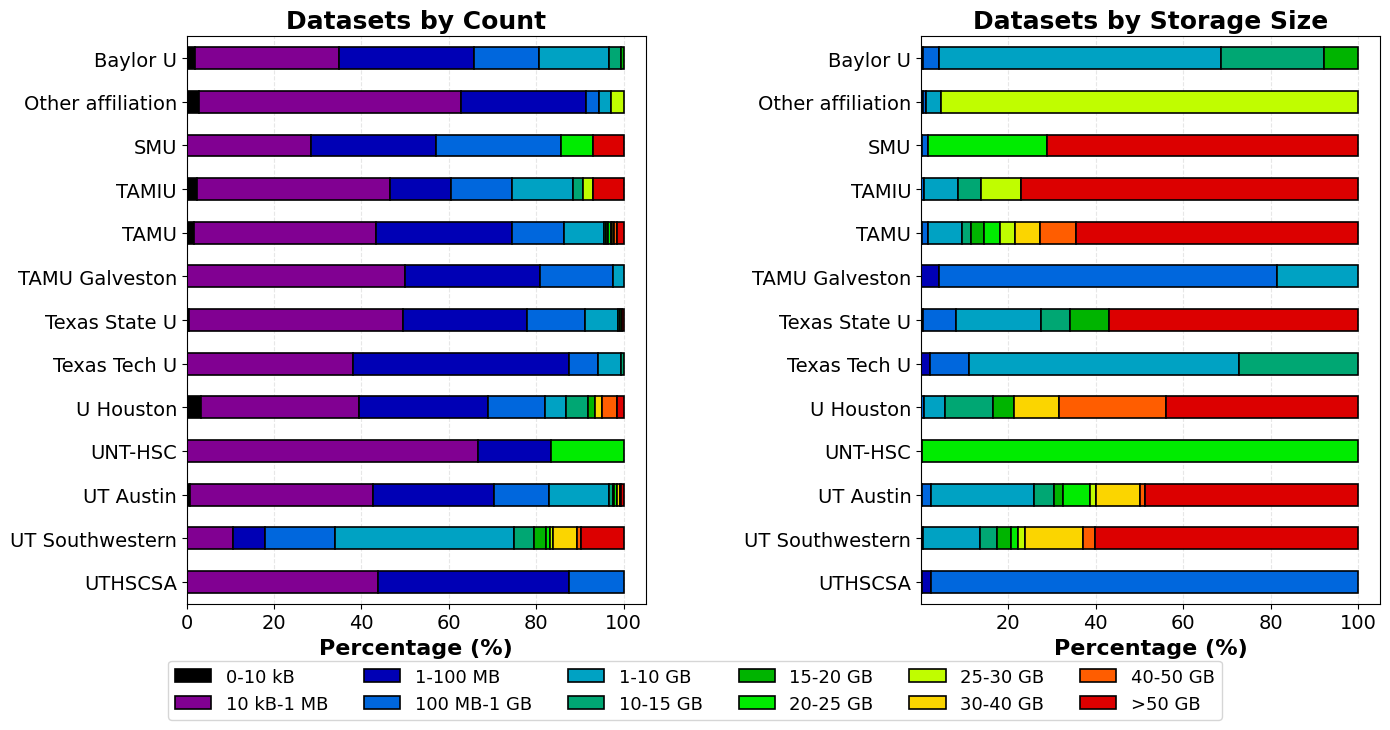

In [477]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(img_width, img_height))

# Colors (same for both)
colors = plt.cm.nipy_spectral(np.linspace(0, 0.9, len(all_data_count.columns)))

# LEFT: Count-based
all_data_count.plot(kind='barh', stacked=True, ax=ax1, edgecolor='black', color=colors, linewidth=1.2, legend=False)
ax1.set_xlabel('Percentage (%)', fontsize=axis_font, fontweight='bold')
ax1.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax1.set_title('Datasets by Count', fontsize=title_font, fontweight='bold')
ax1.tick_params(labelsize=tick_font)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# RIGHT: Storage-based
all_data_size.plot(kind='barh', stacked=True, ax=ax2, edgecolor='black', color=colors, linewidth=1.2, legend=False)
ax2.set_xlabel('Percentage (%)', fontsize=axis_font, fontweight='bold')
ax2.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax2.set_title('Datasets by Storage Size', fontsize=title_font, fontweight='bold')
ax2.tick_params(labelsize=tick_font)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Create shared legend below both plots
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, title='', loc='lower center', 
           bbox_to_anchor=(0.5, -0.05), ncol=6, fontsize=legend_font, 
           title_fontsize=13, frameon=True)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.subplots_adjust(wspace=0.6)
plt.show()

## Slide 16: Cumulative Collections Over Time

YearMonth_published
2017-01       1
2017-03       5
2017-04       7
2017-05      12
2017-06      20
           ... 
2026-01    1046
2026-02    1061
2026-03    1067
2026-04    1076
2026-05    1088
Length: 111, dtype: int64


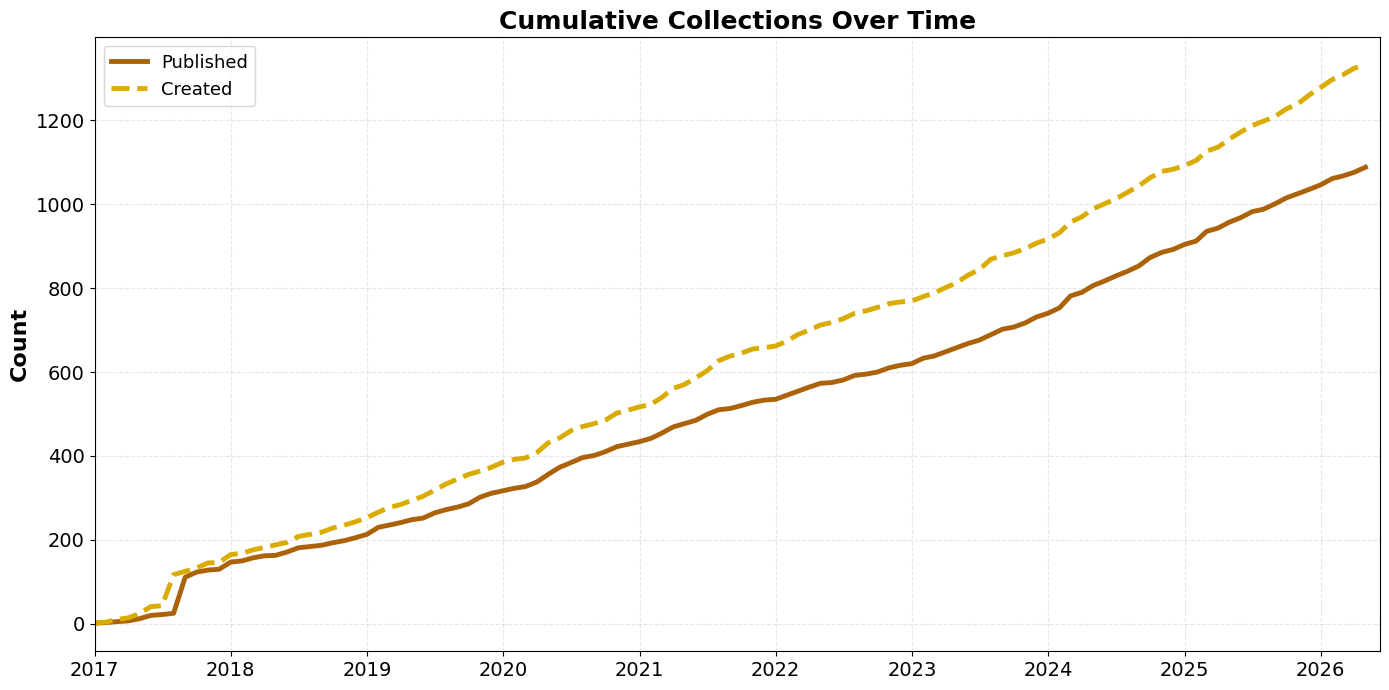

In [478]:
#| echo: false
#| warning: false

# Count records per month - published
monthly_counts_published = dataverses_actual.groupby('YearMonth_published').size()
# Count records per month - creation
monthly_counts_creation = dataverses_actual.groupby('year_month_created').size()

# Convert to cumulative sum
cumulative_counts_published = monthly_counts_published.cumsum()
cumulative_counts_creation = monthly_counts_creation.cumsum()
print(cumulative_counts_published)

## Convert period index to timestamp for plotting
cumulative_counts_published.index = pd.to_datetime(cumulative_counts_published.index)
cumulative_counts_creation.index = pd.to_datetime(cumulative_counts_creation.index)

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))

# Plot both lines
ax.plot(cumulative_counts_published.index, cumulative_counts_published.values, 
        color="#AB6209", linewidth=3.5, label='Published')

ax.plot(cumulative_counts_creation.index, cumulative_counts_creation.values, 
        color="#DBAC00", linewidth=3.5, linestyle='dashed', label='Created')

# Customize the plot
ax.set_xlabel('', fontsize=axis_font, fontweight='bold')
ax.set_xlim(pd.Timestamp('2017-01-01'), today)
ax.set_ylabel('Count', fontsize=axis_font, fontweight='bold')
ax.set_title('Cumulative Collections Over Time', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=legend_font, loc='upper left')

# Adjust layout
plt.tight_layout()

# Display
plt.show()

## Slide 17: Collection Publication & Creation by Institution

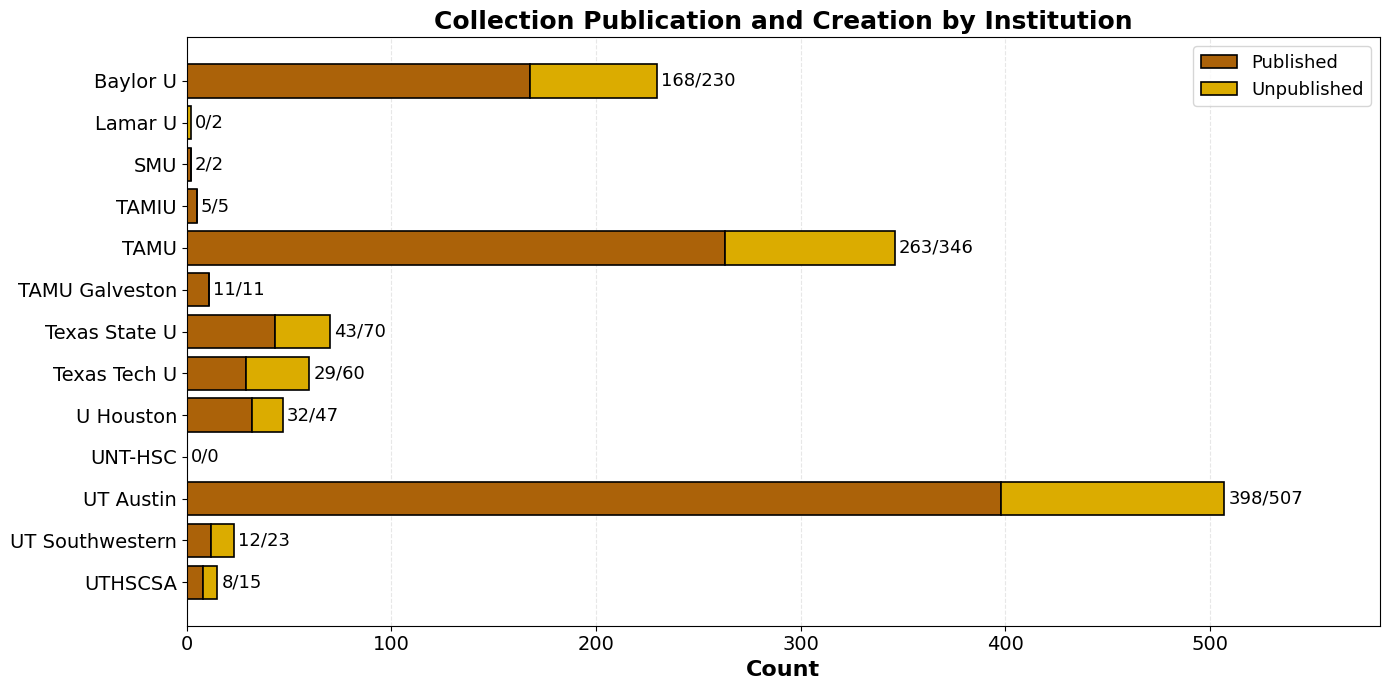

In [479]:
dataverses_plot = dataverses_actual.copy()

# Create published and unpublished counts
dataverses_released = dataverses_plot[dataverses_plot['released'] == 'Yes'].groupby('institution_standardized').size()
dataverses_unreleased = dataverses_plot[dataverses_plot['released'] == 'No'].groupby('institution_standardized').size()

# Reindex to current_members and sort descending
schools_sorted = sorted(current_members, reverse=True)
released_data = dataverses_released.reindex(schools_sorted, fill_value=0)
unreleased_data = dataverses_unreleased.reindex(schools_sorted, fill_value=0)
total_data = released_data + unreleased_data

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))

y_pos = np.arange(len(schools_sorted))

# Plot stacked bars (released on left, unreleased on right)
ax.barh(y_pos, released_data.values, label='Published', 
        color="#AB6209", edgecolor='black', linewidth=1.2)
ax.barh(y_pos, unreleased_data.values, 
        left=released_data.values, label='Unpublished', 
        color="#DBAC00", edgecolor='black', linewidth=1.2)

# Add P/U labels to the right of bars
label_offset = 2
for i, (released_val, unreleased_val) in enumerate(zip(released_data.values, unreleased_data.values)):
    total_width = released_val + unreleased_val
    ax.text(total_width + label_offset, i, f'{int(released_val)}/{int(total_width)}', 
            ha='left', va='center', fontsize=13)

ax.set_yticks(y_pos)
ax.set_yticklabels(schools_sorted)
ax.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
ax.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax.set_title('Collection Publication and Creation by Institution', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=legend_font, loc='upper right')

# Increase x-axis max for label space
x_max = total_data.max()
ax.set_xlim(0, x_max * 1.15)

plt.tight_layout()
plt.show()

## Slide 19: Cumulative Datasets Over Time

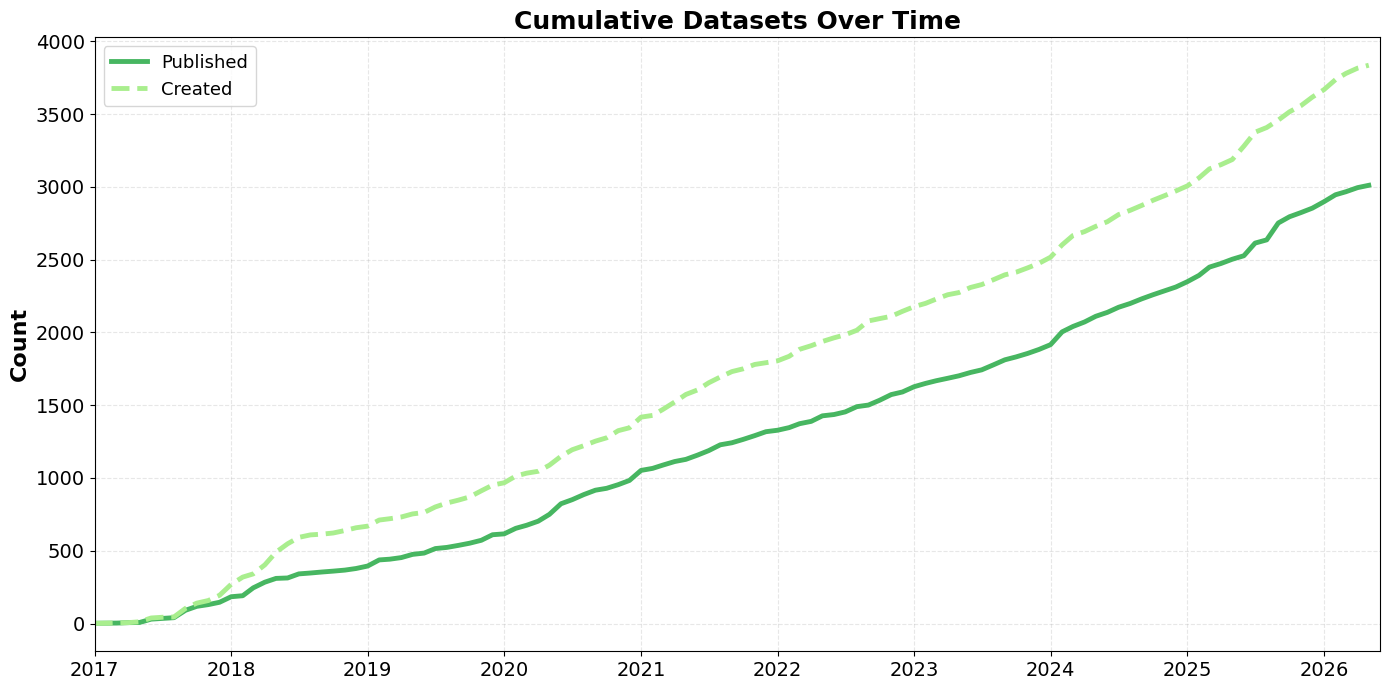

In [480]:
#| echo: false
#| warning: false

fig, ax = plt.subplots(figsize=(img_width, img_height))

# Define colors and line styles for each category
styles = {
    'Created': {'color': "#a9ee8e", 'linestyle': 'dashed', 'linewidth': 3.5},
    'Published': {'color': "#47b661", 'linestyle': 'solid', 'linewidth': 3.5}
}

for category in dataset_concat['category'].unique():
    data = dataset_concat[dataset_concat['category'] == category]
    style = styles[category]
    
    ax.plot(data['year_month'], data['total'], 
            label=category,
            color=style['color'], 
            linestyle=style['linestyle'],
            linewidth=style['linewidth'])

# Customize the plot
ax.set_xlabel('', fontsize=axis_font, fontweight='bold')
ax.set_xlim(pd.Timestamp('2017-01-01'), pd.Timestamp('2026-05-31'))
ax.set_ylabel('Count', fontsize=axis_font, fontweight='bold')
ax.set_title('Cumulative Datasets Over Time', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=legend_font, loc='upper left')

plt.tight_layout()
plt.show()

## Slide 20: Dataset Publication & Creation by Institution

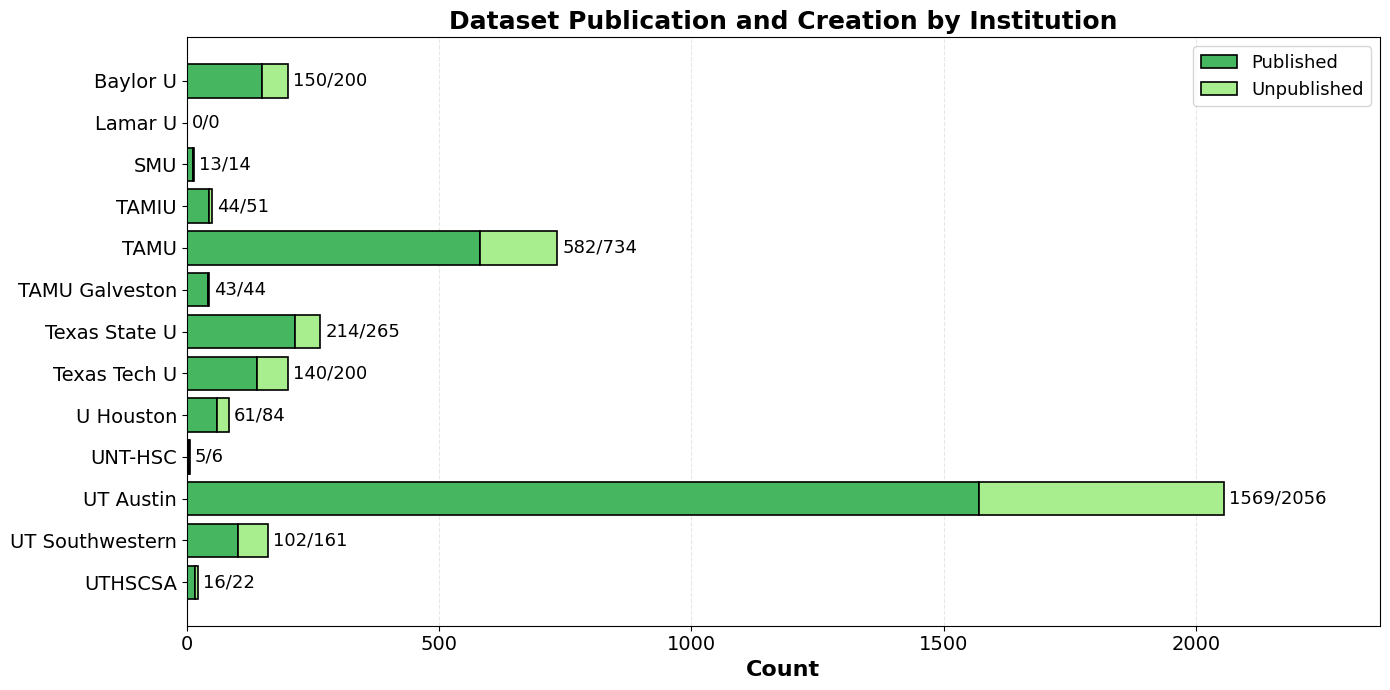

In [481]:
# Filter data for all current members and sort alphabetically
datasets_created_by_affiliation = datasets['institution_standardized'].groupby(datasets['institution_standardized']).count().reindex(current_members, fill_value=0)
datasets_created_by_affiliation = datasets_created_by_affiliation.sort_index(ascending=False)

datasets_published_by_affiliation = datasets_published_df['institution_standardized'].groupby(datasets_published_df['institution_standardized']).count().reindex(current_members, fill_value=0)
datasets_published_by_affiliation = datasets_published_by_affiliation.sort_index(ascending=False)

schools_sorted = sorted(current_members, reverse=True)

created_data = datasets_created_by_affiliation.reindex(schools_sorted, fill_value=0)
published_data = datasets_published_by_affiliation.reindex(schools_sorted, fill_value=0)

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))

y_pos = np.arange(len(schools_sorted))

# Plot stacked bars (published on left, created on right)
ax.barh(y_pos, published_data.values, label='Published', 
        color="#47b661", edgecolor='black', linewidth=1.2)
ax.barh(y_pos, created_data.values - published_data.values, 
        left=published_data.values, label='Unpublished', 
        color="#a9ee8e", edgecolor='black', linewidth=1.2)

# Add P/C labels to the right of bars
label_offset = 10  # Fixed distance from end of bar
for i, (created_val, published_val) in enumerate(zip(created_data.values, published_data.values)):
    total_width = created_val
    ax.text(total_width + label_offset, i, f'{int(published_val)}/{int(created_val)}', 
            ha='left', va='center', fontsize=13)

ax.set_yticks(y_pos)
ax.set_yticklabels(schools_sorted)
ax.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
ax.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax.set_title('Dataset Publication and Creation by Institution', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=legend_font, loc='upper right')

# Increase x-axis max for label space
x_max = created_data.max()
ax.set_xlim(0, x_max * 1.15)

plt.tight_layout()
plt.show()

## Slide 21: Percent of Datasets that are Published by Institution

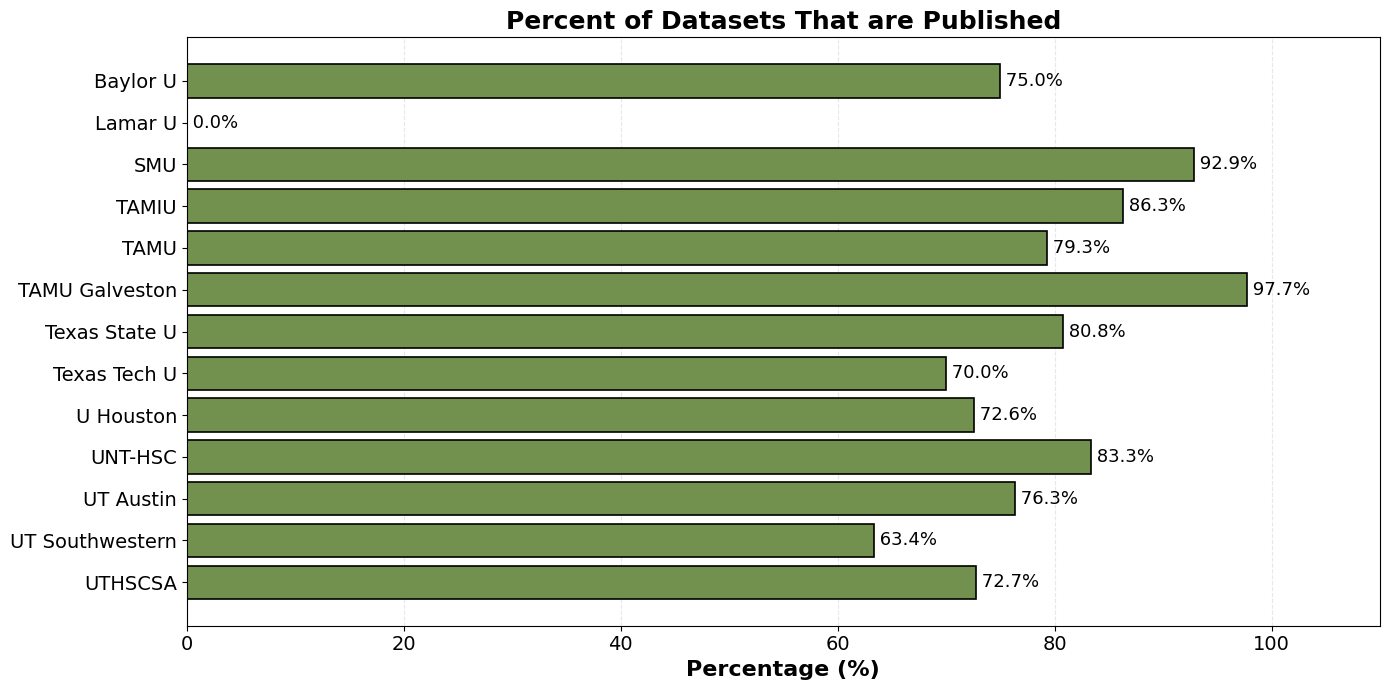

In [482]:
fig, ax = plt.subplots(figsize=(img_width, img_height))

publication_rates = []

for school in current_members:
    created = datasets_created_by_affiliation.get(school, 0)
    published = datasets_published_by_affiliation.get(school, 0)
    if created > 0:
        rate = (published / created) * 100
    else:
        rate = 0
    publication_rates.append((school, rate, created, published))

# Sort by school name in descending alphabetical order
publication_rates.sort(key=lambda x: x[0], reverse=True)

# Extract sorted data
sorted_schools = [f"{item[0]}" for item in publication_rates]
sorted_rates = [item[1] for item in publication_rates]
sorted_school_names = [item[0] for item in publication_rates]

y_pos = np.arange(len(sorted_schools))
colors = [school_colors.get(name, 'gray') for name in sorted_school_names]

ax.barh(y_pos, sorted_rates, color="#72914E", edgecolor='black', linewidth=1.2)

for i, rate in enumerate(sorted_rates):
    ax.text(rate, i, f' {rate:.1f}%', ha='left', va='center', fontsize=13)

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_schools)
ax.set_xlabel('Percentage (%)', fontsize=axis_font, fontweight='bold')
ax.set_title('Percent of Datasets That are Published', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.set_xlim(0, 110)

plt.tight_layout()
plt.show()

## Slide 22: Published Datasets by Subject

C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\2656479571.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20')(np.linspace(1, 0, num_colors))


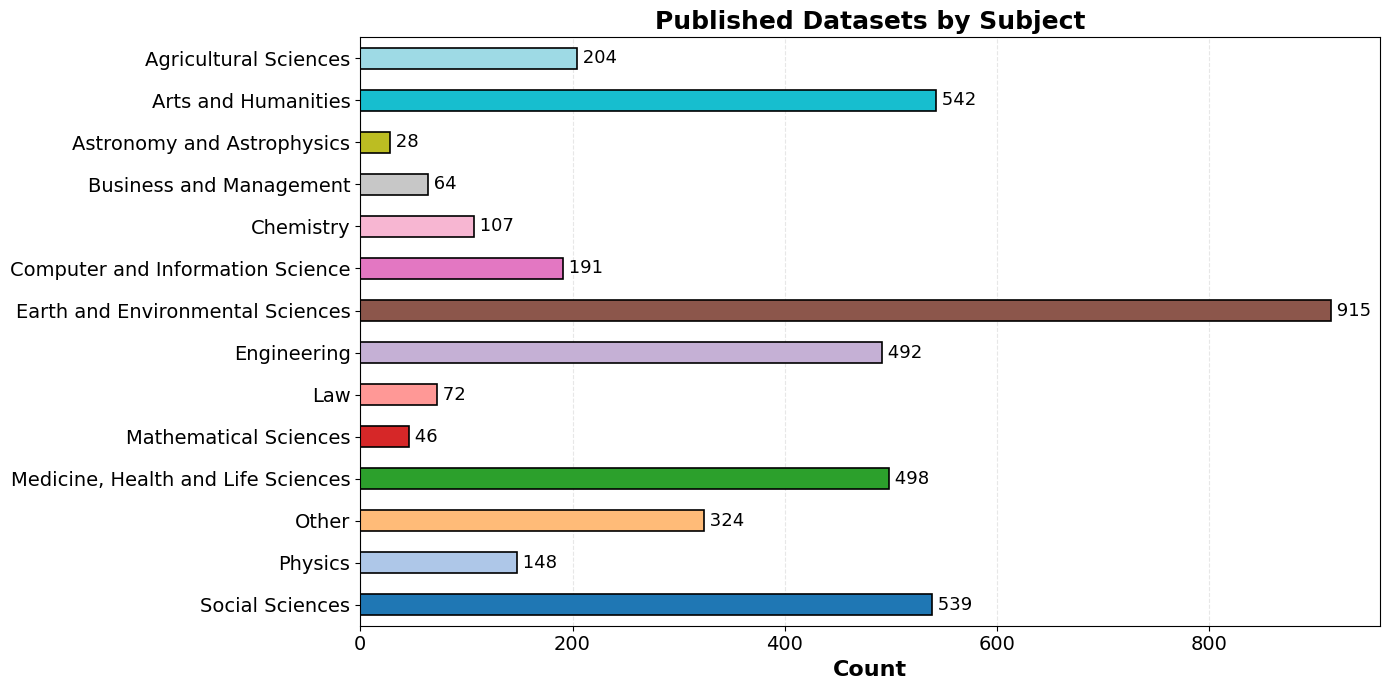

In [483]:
#| echo: false
#| warning: false

datasets_plot = datasets.copy()
datasets_plot['subjects'] = datasets_plot['subjects'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Explode to split multi-subject datasets
df_exploded = datasets_plot.explode('subjects')

# Clean whitespace
## This should not exist in theory
df_exploded['subjects'] = df_exploded['subjects'].str.strip()

# Create color map for all subject-related graphs
all_subjects = sorted(df_exploded['subjects'].dropna().unique())
num_colors = len(all_subjects)
colors = cm.get_cmap('tab20')(np.linspace(1, 0, num_colors))
subject_color_map = {subject: colors[i] for i, subject in enumerate(all_subjects)}
datasets_by_subject = df_exploded['subjects'].groupby(df_exploded['subjects']).count()
datasets_by_subject = datasets_by_subject.sort_index(ascending=False)
bar_colors = [subject_color_map[subject] for subject in datasets_by_subject.index]

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))

# Add value labels
for i, (idx, value) in enumerate(datasets_by_subject.items()):
    ax.text(value, i, f' {int(value)}', va='center', fontsize=13)

# Use the consistent color mapping
datasets_by_subject.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='black', linewidth=1.2)

ax.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
ax.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax.set_title('Published Datasets by Subject', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Slide 23: Relative Proportion of Datasets by Subject and Institution

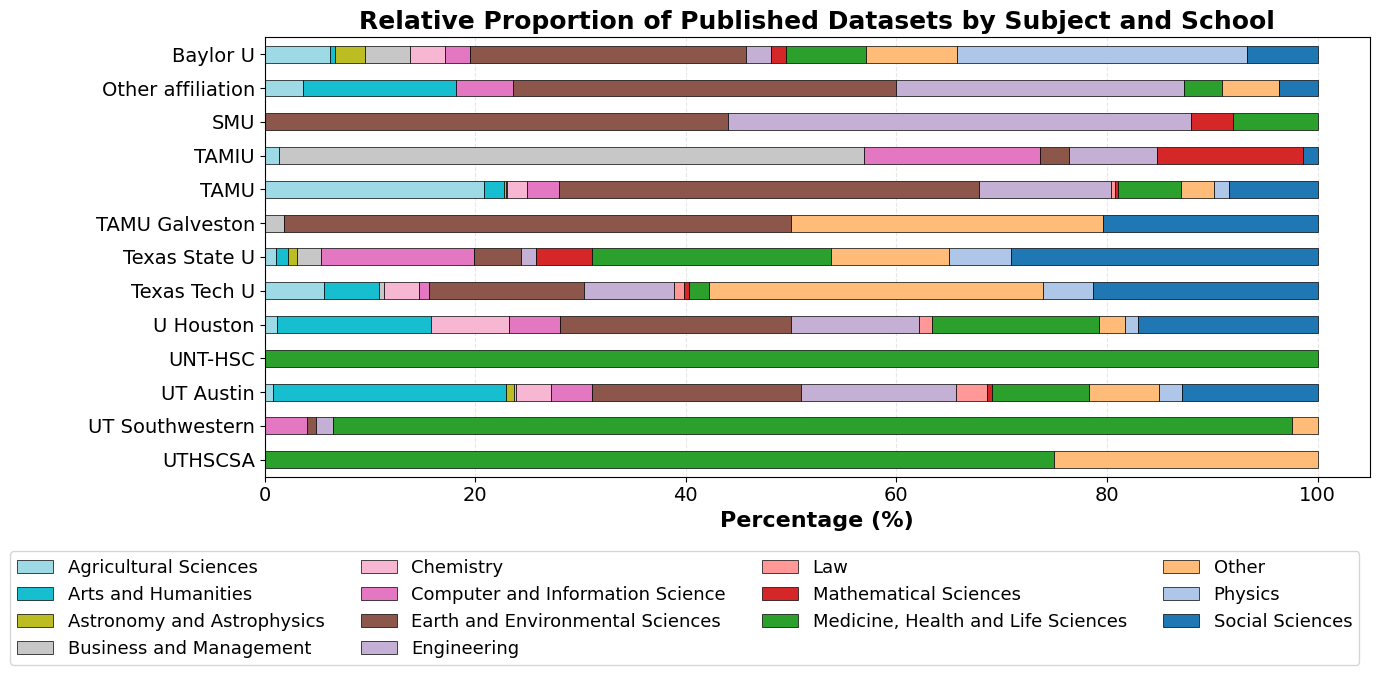

In [484]:
#| echo: false
#| warning: false

datasets_by_subject_school = df_exploded.groupby(['institution_standardized', 'subjects']).size().reset_index(name='count')

pivot_df = datasets_by_subject_school.pivot(index='institution_standardized', columns='subjects', values='count').fillna(0)
pivot_df = pivot_df.sort_index(ascending=False)

# Calculate percentages (relative counts)
pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))

# Map colors to the columns in pivot_pct
plot_colors = [subject_color_map[subject] for subject in pivot_pct.columns]

pivot_pct.plot(kind='barh', stacked=True, ax=ax, color=plot_colors, edgecolor='black', linewidth=0.5)

# Labels, etc.
ax.set_xlabel('Percentage (%)', fontsize=axis_font, fontweight='bold')
ax.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax.set_title('Relative Proportion of Published Datasets by Subject and School', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.legend(title='', bbox_to_anchor=(0.38, -0.15), loc='upper center', fontsize=legend_font, ncol=4)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Slide 24: Dataset Metrics by Metric Bin

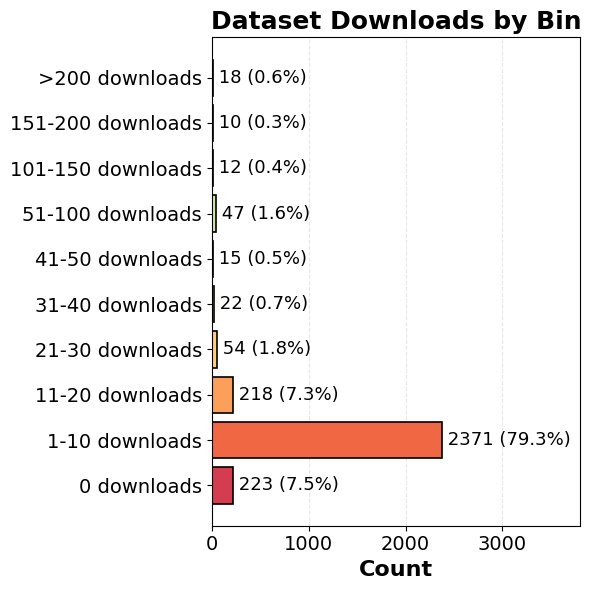

In [485]:
#| echo: false
#| warning: false
# Create the figure and axis
datasets_plot = datasets.copy()

# Create bins for last login
def bin_downloads(count):
    if pd.isna(count):
        return 'Unpublished'
    elif count == 0:
        return '0 downloads'
    elif count <= 10:
        return '1-10 downloads'
    elif count <= 20:
        return '11-20 downloads'
    elif count <= 30:
        return '21-30 downloads'
    elif count <= 40:
        return '31-40 downloads'
    elif count <= 50:
        return '41-50 downloads'
    elif count <= 100:
        return '51-100 downloads'
    elif count <= 150:
        return '101-150 downloads'
    elif count <= 200:
        return '151-200 downloads'
    else:
        return '>200 downloads'

datasets_plot['downloads_bin'] = datasets_plot['downloads_dc'].apply(bin_downloads)
downloads_count = datasets_plot['downloads_bin'].value_counts()

category_order = [
    # 'Unpublished',
    '0 downloads',
    '1-10 downloads',
    '11-20 downloads',
    '21-30 downloads',
    '31-40 downloads',
    '41-50 downloads',
    '51-100 downloads',
    '101-150 downloads',
    '151-200 downloads',
    '>200 downloads'
]

n_categories = len(category_order)

# Reorder the series
downloads_count = downloads_count.reindex(category_order)

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(6, 6))

# Create horizontal bar plot
colors = cm.Spectral(np.linspace(0.1, 0.9, n_categories))
bars = ax.barh(range(len(downloads_count)), downloads_count.values, color=colors, edgecolor='black', linewidth=1.2)

# Customize the plot
ax.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
ax.set_title('Dataset Downloads by Bin', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.set_xlim(0, 3000)

# Set y-axis labels
ax.set_yticks(range(len(downloads_count)))
ax.set_yticklabels(downloads_count.index)

# Add value labels at the end of bars
for idx, (bar, value) in enumerate(zip(bars, downloads_count.values)):
    width = bar.get_width()
    pct = (value / downloads_count.sum()) * 100
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(value)} ({pct:.1f}%)',
            ha='left', va='center', fontsize=13)

# Add grid for readability
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.set_xlim(0, 3800)

# Adjust layout
plt.tight_layout()

# Display
plt.show()

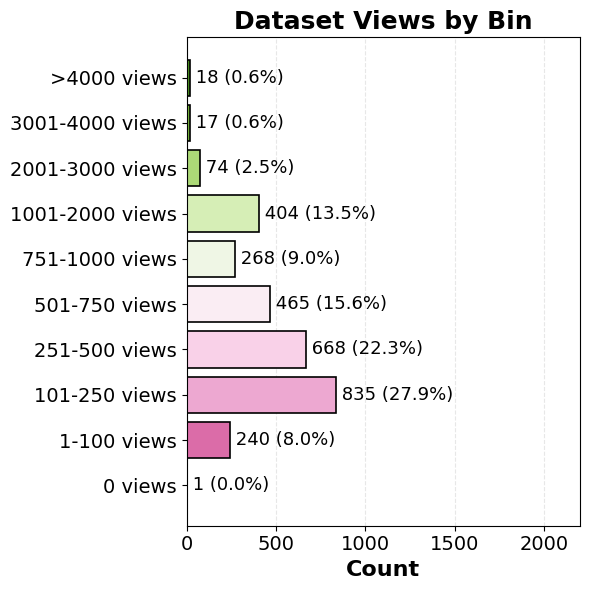

In [486]:
#| echo: false
#| warning: false

# Create bins for last login
def bin_views(count):
    if pd.isna(count):
        return 'Unpublished'
    elif count == 0:
        return '0 views'
    elif count <= 100:
        return '1-100 views'
    elif count <= 250:
        return '101-250 views'
    elif count <= 500:
        return '251-500 views'
    elif count <= 750:
        return '501-750 views'
    elif count <= 1000:
        return '751-1000 views'
    elif count <= 2000:
        return '1001-2000 views'
    elif count <= 3000:
        return '2001-3000 views'
    elif count <= 4000:
        return '3001-4000 views'
    else:
        return '>4000 views'

datasets_plot['views_bin'] = datasets_plot['views_dc'].apply(bin_views)

views_count = datasets_plot['views_bin'].value_counts()

category_order = [
    # 'Unpublished',
    '0 views',
    '1-100 views',
    '101-250 views',
    '251-500 views',
    '501-750 views',
    '751-1000 views',
    '1001-2000 views',
    '2001-3000 views',
    '3001-4000 views',
    '>4000 views'
]

# Reorder the series
views_count = views_count.reindex(category_order)

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(6, 6))

colors = cm.PiYG(np.linspace(0.1, 0.9, n_categories))
bars = ax.barh(range(len(views_count)), views_count.values, color=colors, edgecolor='black', linewidth=1.2)

# Labels, etc.
ax.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
ax.set_title('Dataset Views by Bin', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.set_xlim(0, 3000)
ax.set_yticks(range(len(views_count)))
ax.set_yticklabels(views_count.index)

# Add value labels at the end of bars
for idx, (bar, value) in enumerate(zip(bars, views_count.values)):
    width = bar.get_width()
    pct = (value / views_count.sum()) * 100
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(value)} ({pct:.1f}%)',
            ha='left', va='center', fontsize=13)

# Add grid for readability
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.set_xlim(0, 2200)

# Adjust layout
plt.tight_layout()

# Display
plt.show()

## Slide 25: Metrics Table

In [487]:
datasets_filtered = datasets_plot[~datasets_plot['institution_standardized'].isin(['No affiliation', 'Other affiliation'])]

# Calculate downloads stats by institution
stats_by_institution = datasets_filtered.groupby('institution_standardized')['downloads_dc'].agg([
    ('Median', 'median'),
    ('Mode', lambda x: x.mode()[0] if len(x.mode()) > 0 else 0),
    ('Max', 'max')
]).sort_values('Median', ascending=False)

# Convert to int, handling NaN values
stats_by_institution = stats_by_institution.fillna(0).astype(int)

# Reset index to make institution a column
stats_table = stats_by_institution.reset_index()
stats_table.columns = ['Institution', 'Median', 'Mode', 'Max']

# Sort by Institution name in descending alphabetical order
stats_table = stats_table.sort_values('Institution', ascending=True)

# Create styled table
styled = stats_table.style\
    .background_gradient(subset=['Median'], cmap='RdYlGn', vmin=stats_table['Median'].min(), vmax=stats_table['Median'].max())\
    .background_gradient(subset=['Mode'], cmap='Blues', vmin=stats_table['Mode'].min(), vmax=stats_table['Mode'].max())\
    .background_gradient(subset=['Max'], cmap='Oranges', vmin=stats_table['Max'].min(), vmax=stats_table['Max'].max())\
    .format({'Median': '{:.0f}', 'Mode': '{:.0f}', 'Max': '{:.0f}'})\
    .set_caption('Download Statistics by Institution')\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', "#35558D"), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
        {'selector': 'caption', 'props': [('text-align', 'center'), ('padding', '10px'), ('font-size', '14pt'), ('font-weight', 'bold')]}
    ])

styled

,Institution,Median,Mode,Max
8,Baylor U,3,2,32
0,SMU,7,0,13
1,TAMIU,5,3,88
5,TAMU,4,3,285
2,TAMU Galveston,5,3,19
3,Texas State U,5,1,480
9,Texas Tech U,3,3,127
4,U Houston,5,3,30
10,UNT-HSC,1,0,6
6,UT Austin,4,2,4268


In [488]:
# Calculate views stats by institution
stats_by_institution = datasets_filtered.groupby('institution_standardized')['views_dc'].agg([
    ('Median', 'median'),
    # ('Mode', lambda x: x.mode()[0] if len(x.mode()) > 0 else 0),
    ('Max', 'max')
]).sort_values('Median', ascending=False)

# Convert to int, handling NaN values
stats_by_institution = stats_by_institution.fillna(0).astype(int)

# Reset index to make institution a column
stats_table = stats_by_institution.reset_index()
stats_table.columns = ['Institution', 'Median', 'Max']

# Sort by Institution name in descending alphabetical order
stats_table = stats_table.sort_values('Institution', ascending=True)

# Create styled table
styled = stats_table.style\
    .background_gradient(subset=['Median'], cmap='RdYlGn', vmin=stats_table['Median'].min(), vmax=stats_table['Median'].max())\
    .background_gradient(subset=['Max'], cmap='Oranges', vmin=stats_table['Max'].min(), vmax=stats_table['Max'].max())\
    .format({'Median': '{:.0f}', 'Max': '{:.0f}'})\
    .set_caption('View Statistics by Institution')\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#35558D'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
        {'selector': 'caption', 'props': [('text-align', 'center'), ('padding', '10px'), ('font-size', '14pt'), ('font-weight', 'bold')]}
    ])

styled

,Institution,Median,Max
0,Baylor U,595,2664
2,SMU,465,1522
1,TAMIU,548,2518
9,TAMU,277,3481
4,TAMU Galveston,427,5326
8,Texas State U,320,9821
11,Texas Tech U,200,9018
10,U Houston,253,3615
5,UNT-HSC,413,889
3,UT Austin,446,9452


## Slide 28: File Count by Total Files

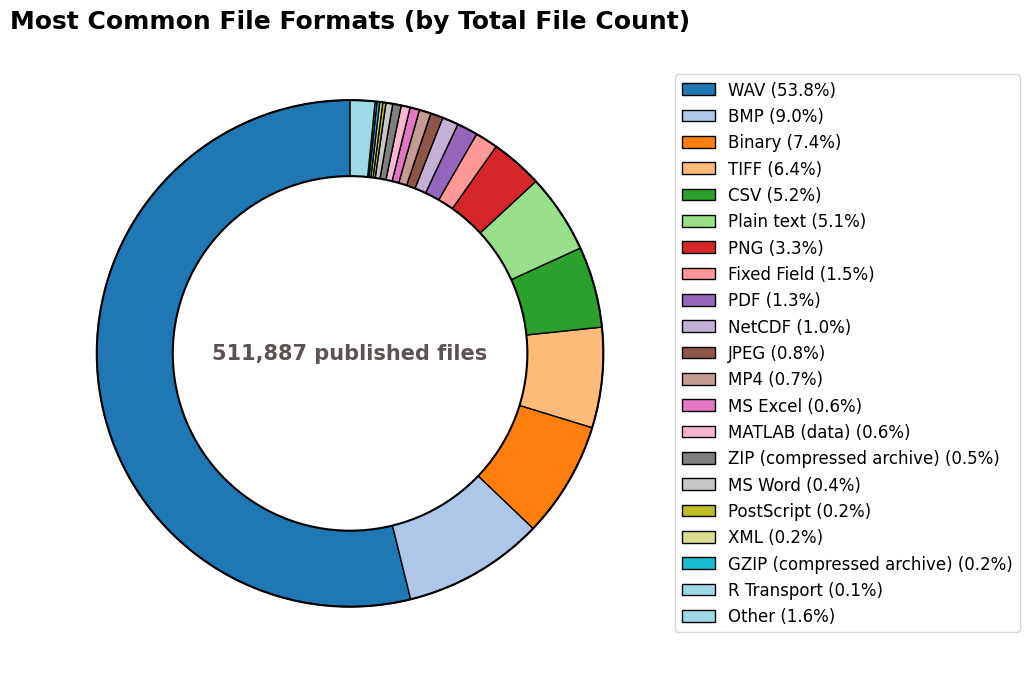

In [489]:
#| echo: false
#| warning: false

files_plot = files.copy()

files_by_type = files_plot['friendly_format_manual'].groupby(files_plot['friendly_format_manual']).count()
files_by_type = files_by_type.sort_values(ascending=False)

cut = 20
top = files_by_type.head(cut)
other_count = files_by_type.iloc[cut:].sum()

# Create new series with 'Other' category
if other_count > 0:
    files_by_type = pd.concat([top, pd.Series({'Other': other_count})])
else:
    files_by_type = top

fig, ax = plt.subplots(figsize=(img_width, img_height))

colors = plt.cm.tab20(range(len(files_by_type)))

wedges, texts, autotexts = ax.pie(
    files_by_type.values,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 10, 'weight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

border = Circle((0, 0), 1, fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(border)

# Make percentage text white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

# Remove the label text around the donut
for text in texts:
    text.set_visible(False)

# Draw circle in the center to create donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white', color='black', linewidth=1.5)
ax.add_artist(centre_circle)

# Add count to middle
total_count = len(files_plot)
ax.text(0, 0, f'{total_count:,} published files', ha='center', va='center', 
        fontsize=15, fontweight='bold', color="#5C5252")

# Create legend with labels and percentages
legend_labels = [f'{label} ({value/files_by_type.sum()*100:.1f}%)' 
                 for label, value in files_by_type.items()]
ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

ax.set_title('Most Common File Formats (by Total File Count)', fontsize=title_font, fontweight='bold')
plt.tight_layout()
plt.show()

## Slide 29: Comparison of File Count Methods

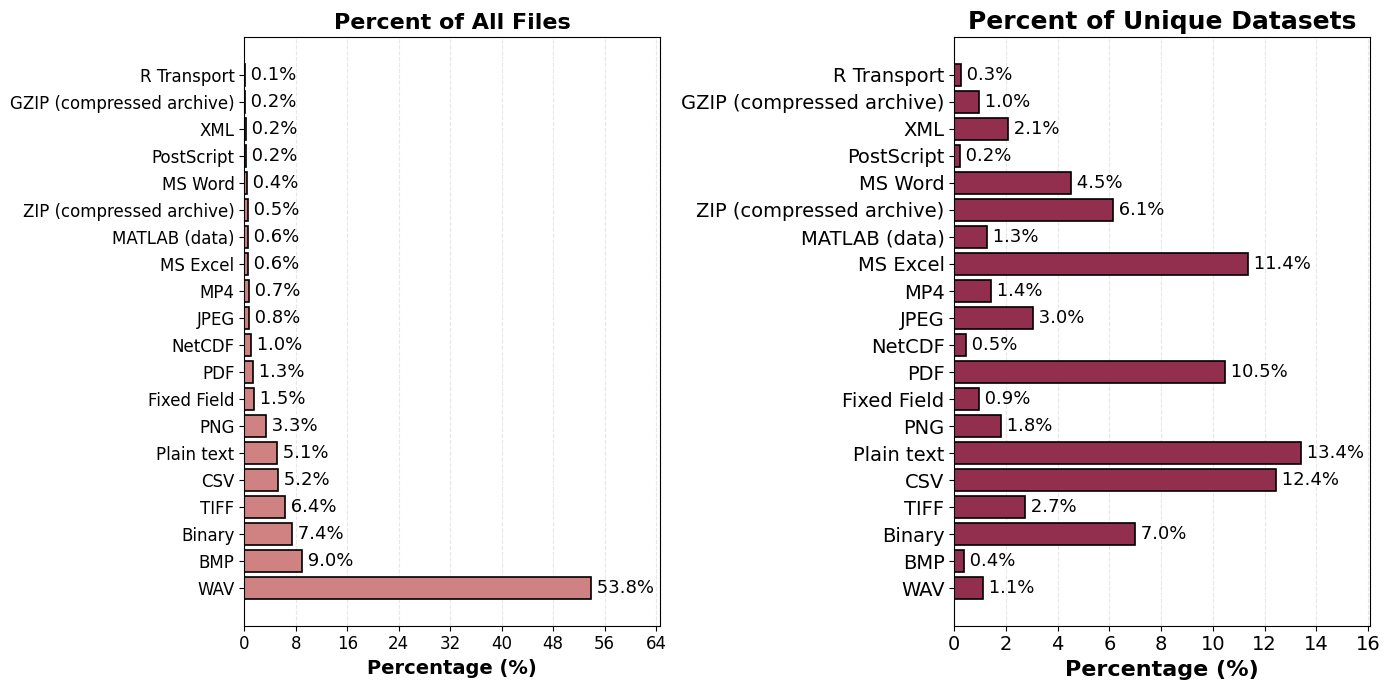

In [490]:
# Get top N (cut) formats by total file count
files_by_type = files_plot['friendly_format_manual'].groupby(files_plot['friendly_format_manual']).count()
files_by_type = files_by_type.sort_values(ascending=False)
cut = 20
top = files_by_type.head(cut)
other_count = files_by_type.iloc[cut:].sum()

# Create new series with 'Other' category
if other_count > 0:
    files_by_type = pd.concat([top, pd.Series({'Other': other_count})])
else:
    files_by_type = top

total = files_by_type.sum()
files_by_type_pct = (files_by_type / total) * 100
top_formats_all = files_by_type_pct.head(cut)

files_plot = files.copy()

files_plots_dedup = files_plot.drop_duplicates(subset=['doi', 'friendly_format_manual'], keep='first')
files_by_dataset = files_plots_dedup['friendly_format_manual'].groupby(files_plot['friendly_format_manual']).count()
files_by_dataset = files_by_dataset.sort_values(ascending=False)
total = files_by_dataset.sum()
files_by_dataset_pct = (files_by_dataset / total) * 100

# Filter to only formats that are in top 15 by all files
unique_per_dataset_pct = files_by_dataset_pct[files_by_dataset_pct.index.isin(top_formats_all.index)]

# Sort both by top_formats_all (descending)
top_formats_all = top_formats_all.sort_values(ascending=False)
unique_per_dataset_pct = unique_per_dataset_pct[top_formats_all.index]

# Create figure with 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(img_width, img_height))

y_pos = np.arange(len(top_formats_all))
colors = plt.cm.tab20(np.linspace(0, 1, len(top_formats_all)))

# Left plot: All Files percentage
ax1.barh(y_pos, top_formats_all.values, color="#d08282", edgecolor='black', linewidth=1.2)

for i, pct in enumerate(top_formats_all.values):
    ax1.text(pct, i, f' {pct:.1f}%', ha='left', va='center', fontsize=13)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_formats_all.index)
ax1.set_xlabel('Percentage (%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('', fontsize=14, fontweight='bold')
ax1.set_title('Percent of All Files', fontsize=16, fontweight='bold')
ax1.tick_params(labelsize=12)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Add padding for labels
x_max = top_formats_all.max()
ax1.set_xlim(0, x_max * 1.2)

# Right plot: Unique per Dataset percentage
ax2.barh(y_pos, unique_per_dataset_pct.values, color="#922e4e", edgecolor='black', linewidth=1.2)

for i, pct in enumerate(unique_per_dataset_pct.values):
    ax2.text(pct, i, f' {pct:.1f}%', ha='left', va='center', fontsize=13)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(unique_per_dataset_pct.index)
ax2.set_xlabel('Percentage (%)', fontsize=axis_font, fontweight='bold')
ax2.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax2.set_title('Percent of Unique Datasets', fontsize=title_font, fontweight='bold')
ax2.tick_params(labelsize=tick_font)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Add padding for labels
x_max = unique_per_dataset_pct.max()
ax2.set_xlim(0, x_max * 1.2)

# Force percents to integers
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.subplots_adjust(wspace=0.3)
plt.tight_layout()
plt.show()

## Slide 30: File Formats by Unique Dataset Count

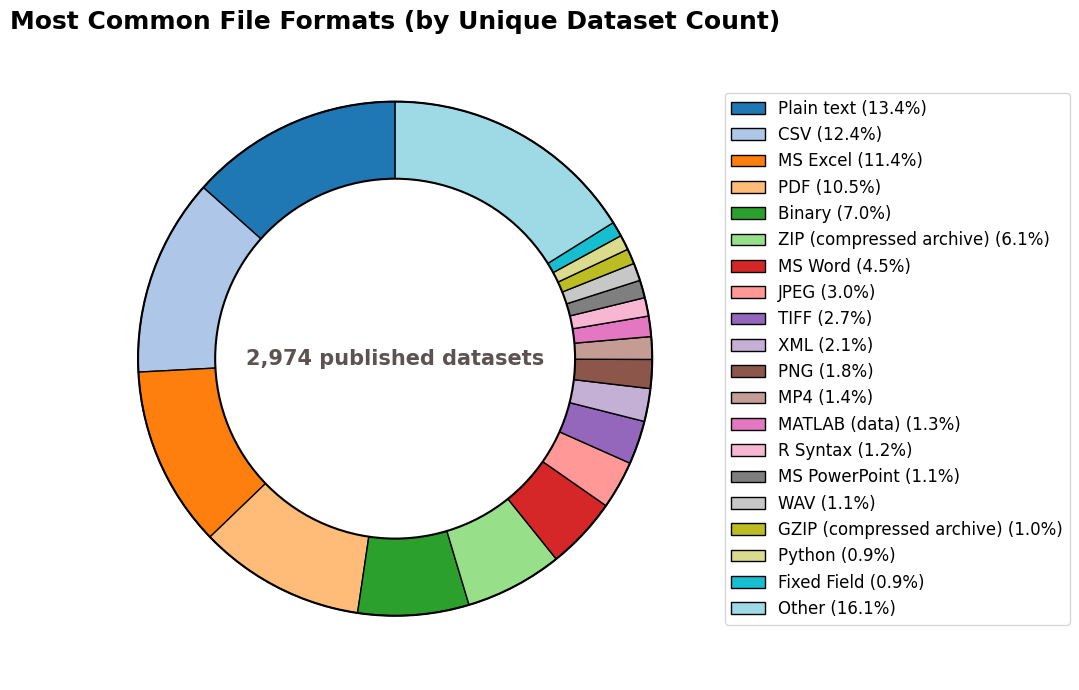

In [491]:
#| echo: false
#| warning: false
from matplotlib.patches import Circle
files_plot = files.copy()

files_plots_dedup = files_plot.drop_duplicates(subset=['doi', 'friendly_format_manual'], keep='first')

files_by_dataset = files_plots_dedup['friendly_format_manual'].groupby(files_plot['friendly_format_manual']).count()
files_by_dataset = files_by_dataset.sort_values(ascending=False)

cut = 19
top = files_by_dataset.head(cut)
other_count = files_by_dataset.iloc[cut:].sum()

# Create new series with 'Other' category
if other_count > 0:
    files_by_dataset = pd.concat([top, pd.Series({'Other': other_count})])
else:
    files_by_dataset = top

fig, ax = plt.subplots(figsize=(img_width, img_height))

colors = plt.cm.tab20(range(len(files_by_dataset)))

wedges, texts, autotexts = ax.pie(
    files_by_dataset.values,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 10, 'weight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

border = Circle((0, 0), 1, fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(border)

# Make percentage text white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

# Remove the label text around the donut
for text in texts:
    text.set_visible(False)

# Draw circle in the center to create donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white', color='black', linewidth=1.5)
ax.add_artist(centre_circle)

# Add count to middle
total_count = len(datasets_published_df)
ax.text(0, 0, f'{total_count:,} published datasets', ha='center', va='center', 
        fontsize=15, fontweight='bold', color="#5C5252")

# Create legend with labels and percentages
legend_labels = [f'{label} ({value/files_by_dataset.sum()*100:.1f}%)' 
                 for label, value in files_by_dataset.items()]
ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

ax.set_title('Most Common File Formats (by Unique Dataset Count)', fontsize=title_font, fontweight='bold')
plt.tight_layout()
plt.show()

## Slide 31: File Formats by Collective Storage

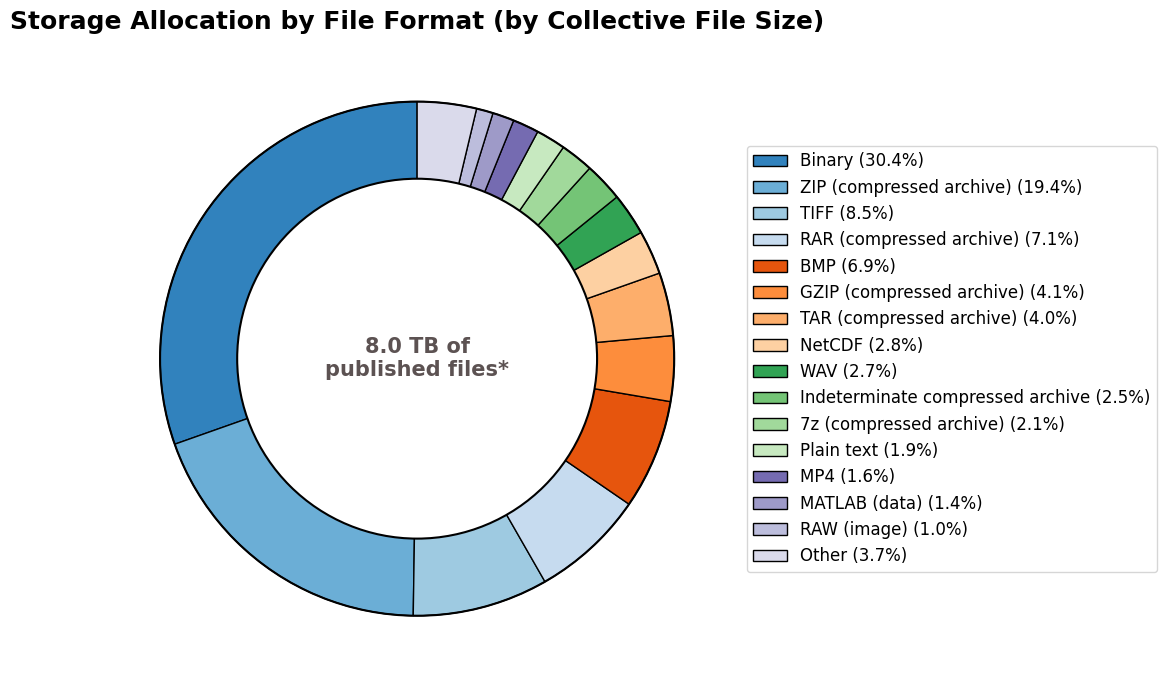

In [492]:
files_plot = files.copy()

# Sum file_size instead of counting
files_by_type = files_plot.groupby('friendly_format_manual')['file_size'].sum()
files_by_type = files_by_type.sort_values(ascending=False)

cut = 15
top = files_by_type.head(cut)
other_count = files_by_type.iloc[cut:].sum()

# Create new series with 'Other' category
if other_count > 0:
    files_by_type = pd.concat([top, pd.Series({'Other': other_count})])
else:
    files_by_type = top

fig, ax = plt.subplots(figsize=(img_width, img_height))

colors = plt.cm.tab20c(range(len(files_by_type)))

wedges, texts, autotexts = ax.pie(
    files_by_type.values,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 10, 'weight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

border = Circle((0, 0), 1, fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(border)

# Make percentage text white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

# Remove the label text around the donut
for text in texts:
    text.set_visible(False)

# Draw circle in the center to create donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white', color='black', linewidth=1.5)
ax.add_artist(centre_circle)

# Add total size to middle (convert bytes to GB)
total_size_tb = files_by_type.sum() / (1024**4)
ax.text(0, 0, f'{total_size_tb:,.1f} TB of\npublished files*', ha='center', va='center', 
        fontsize=15, fontweight='bold', color="#5C5252")

# Create legend with labels and percentages (also show size in GB)
# legend_labels = [f'{label} ({value/(1024**3):,.1f} GB, {value/files_by_type.sum()*100:.1f}%)' 
#                  for label, value in files_by_type.items()]
legend_labels = [f'{label} ({value/files_by_type.sum()*100:.1f}%)' 
                 for label, value in files_by_type.items()]
ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

ax.set_title('Storage Allocation by File Format (by Collective File Size)', fontsize=title_font, fontweight='bold')
plt.tight_layout()
plt.show()

In [493]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor

write_ppt = True
if not write_ppt:
    sys.exit()

# Define output directory for writing slide-decks
output_dir = 'institutional-reports'

# Create directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

In [494]:
def create_users_and_creators_trend(inst_data, institution_name):
    """
    Create cumulative trend chart for Users, Dataset creators, and Collection creators
    
    Parameters:
    - inst_data: filtered dataframe for the institution
    - institution_name: str, name of institution
    """
    
    fig, ax = plt.subplots(figsize=(img_width, img_height))
    
    # Define colors and line styles for each category
    styles = {
        'Users': {'color': "#3c68ee", 'linestyle': 'solid', 'linewidth': 3.5},
        'Dataset creators': {'color': "#05A00D", 'linestyle': 'dotted', 'linewidth': 3.5},
        'Collection creators': {'color': "#E4CF58", 'linestyle': 'dashed', 'linewidth': 3.5}
    }
    
    for category in inst_data['category'].unique():
        data = inst_data[inst_data['category'] == category]
        style = styles[category]
        
        ax.plot(data['year_month_created'], data['total'], 
                label=category,
                color=style['color'], 
                linestyle=style['linestyle'],
                linewidth=style['linewidth'])
    
    # Labels and formatting
    ax.set_xlabel('', fontsize=axis_font, fontweight='bold')
    ax.set_xlim(pd.Timestamp('2017-01-01'), pd.Timestamp('2026-05-31'))
    ax.set_ylabel('Cumulative Count', fontsize=axis_font, fontweight='bold')
    # ax.set_title('Users and Creators Over Time', fontsize=title_font, fontweight='bold')
    ax.tick_params(labelsize=tick_font)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Add legend
    ax.legend(fontsize=legend_font, loc='upper left')
    
    plt.tight_layout()

    return fig

def create_storage_allocation_trend(storage_summary, institution_name):
    """
    Create stacked area chart for cumulative storage allocation (Published vs Unpublished)
    
    Parameters:
    - storage_summary: dataframe with columns ['year_month', 'published', 'unpublished']
    - institution_name: str, name of institution
    """
    
    fig, ax = plt.subplots(figsize=(img_width, img_height))
    
    files_aligned = storage_summary['published']
    datasets_aligned = storage_summary['unpublished']
    
    ax.fill_between(storage_summary['year_month'], 0, files_aligned.values, alpha=0.6, color="#831ab8", label='Published')
    ax.fill_between(storage_summary['year_month'], files_aligned.values, files_aligned.values + datasets_aligned.values, alpha=0.6, color="#c299d7", label='Unpublished')
    
    # Plot the lines on top
    ax.plot(storage_summary['year_month'], files_aligned.values, color="#831ab8", linewidth=2.5)
    ax.plot(storage_summary['year_month'], files_aligned.values + datasets_aligned.values, color="#c299d7", linewidth=2.5)
    
    # Customize the plot
    ax.set_xlabel('', fontsize=axis_font, fontweight='bold')
    ax.set_xlim(pd.Timestamp('2017-01-01'), pd.Timestamp('2026-05-31'))
    ax.set_ylabel('Storage (TB)', fontsize=axis_font, fontweight='bold')
    # ax.set_title('Cumulative Storage Allocation over Time', fontsize=tick_font, fontweight='bold')
    ax.tick_params(labelsize=tick_font)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    ax.legend(fontsize=legend_font, loc='upper left')
    
    plt.tight_layout()

    return fig

def create_dataset_size_distribution(inst_datasets, institution_name, bin_labels):
    """
    Create dual-panel bar chart for dataset size distribution
    
    Parameters:
    - inst_datasets: filtered dataframe for the institution (datasets dataframe)
    - institution_name: str, name of institution
    - bin_labels: list, ordered list of dataset size bin labels
    """
    
    datasets_plot = inst_datasets.copy()
    
    # Counting datasets in each size bin
    datasets_by_size = datasets_plot.groupby(['dataset_size_bin']).size().reset_index(name='count')
    datasets_by_size = datasets_by_size.set_index('dataset_size_bin')
    datasets_by_size = datasets_by_size.reindex(bin_labels[::-1], fill_value=0)
    
    # Counting total storage size in each size bin
    datasets_size_sum = datasets_plot.groupby('dataset_size_bin')['dataset_size'].sum().reset_index(name='total_size')
    datasets_size_sum = datasets_size_sum.set_index('dataset_size_bin')
    datasets_size_sum = datasets_size_sum.reindex(bin_labels[::-1], fill_value=0)
    datasets_size_sum['total_size_tb'] = datasets_size_sum['total_size'] / (1024**4)
    
    # Create plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(img_width, img_height))
    
    # Only use colors for bins that have data
    num_bins = len(datasets_by_size)
    colors = plt.cm.nipy_spectral(np.linspace(0.9, 0, num_bins))
    
    y_pos = np.arange(len(datasets_by_size))
    
    # Left panel: Dataset count by size bin
    ax1.barh(y_pos, datasets_by_size['count'].values, 
            color=colors, edgecolor='black', linewidth=1.2)
    
    # Add value labels
    for i, count in enumerate(datasets_by_size['count'].values):
        if count > 0:
            ax1.text(count, i, f' {int(count)}', ha='left', va='center', fontsize=13)
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(datasets_by_size.index)
    ax1.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
    ax1.set_ylabel('', fontsize=axis_font, fontweight='bold')
    ax1.set_title('Dataset Count', fontsize=title_font, fontweight='bold')
    ax1.tick_params(labelsize=tick_font)
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    ax1.set_axisbelow(True)
    
    # Add padding for labels
    x_max = datasets_by_size['count'].max()
    if x_max > 0:
        ax1.set_xlim(0, x_max * 1.2)
    
    # Right panel: Storage allocation by size bin
    y_pos = np.arange(len(datasets_size_sum))
    
    ax2.barh(y_pos, datasets_size_sum['total_size_tb'].values, 
            color=colors, edgecolor='black', linewidth=1.2)
    
    # Add value labels (convert TB to GB for display)
    for i, size_tb in enumerate(datasets_size_sum['total_size_tb'].values):
        if size_tb > 0:
            size_gb = size_tb * 1024
            ax2.text(size_tb, i, f' {size_gb:.1f} GB', ha='left', va='center', fontsize=13)
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(datasets_size_sum.index)
    ax2.set_xlabel('Storage (TB)', fontsize=axis_font, fontweight='bold')
    ax2.set_ylabel('', fontsize=axis_font, fontweight='bold')
    ax2.set_title('Storage Allocation', fontsize=title_font, fontweight='bold')
    ax2.tick_params(labelsize=tick_font)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')
    ax2.set_axisbelow(True)
    
    # Add padding for labels
    x_max = datasets_size_sum['total_size_tb'].max()
    if x_max > 0:
        ax2.set_xlim(0, x_max * 1.3)
    
    # Add space between plots
    plt.subplots_adjust(wspace=0.3)
    plt.tight_layout()
    
    return fig

def create_collections_trend(inst_dataverses, institution_name):
    """
    Create cumulative trend chart for Collections (published vs created)
    
    Parameters:
    - inst_dataverses: filtered dataframe for the institution (dataverses dataframe)
    - institution_name: str, name of institution
    """
    
    # Count records per month - published
    monthly_counts_published = inst_dataverses.groupby('YearMonth_published').size()
    # Count records per month - creation
    monthly_counts_creation = inst_dataverses.groupby('year_month_created').size()
    
    # Convert to cumulative sum
    cumulative_counts_published = monthly_counts_published.cumsum()
    cumulative_counts_creation = monthly_counts_creation.cumsum()
    
    # Convert period index to timestamp for plotting
    cumulative_counts_published.index = pd.to_datetime(cumulative_counts_published.index)
    cumulative_counts_creation.index = pd.to_datetime(cumulative_counts_creation.index)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(img_width, img_height))
    
    # Plot both lines
    ax.plot(cumulative_counts_published.index, cumulative_counts_published.values, 
            color="#AB6209", linewidth=3.5, label='Published')
    
    ax.plot(cumulative_counts_creation.index, cumulative_counts_creation.values, 
            color="#DBAC00", linewidth=3.5, linestyle='dashed', label='Created')
    
    # Customize the plot
    ax.set_xlabel('', fontsize=axis_font, fontweight='bold')
    ax.set_xlim(pd.Timestamp('2017-01-01'), pd.Timestamp('2026-05-31'))
    ax.set_ylabel('Count', fontsize=axis_font, fontweight='bold')
    # ax.set_title('Cumulative Collections Over Time', fontsize=title_font, fontweight='bold')
    ax.tick_params(labelsize=tick_font)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=legend_font, loc='upper left')
    
    # Adjust layout
    plt.tight_layout()
    
    return fig

def create_datasets_trend(inst_datasets, institution_name):
    """
    Create cumulative trend chart for Datasets (created vs published)
    
    Parameters:
    - inst_datasets: filtered dataframe for the institution (datasets dataframe)
    - institution_name: str, name of institution
    """
    
    # Datasets created - count by creation date
    monthly_counts_created = inst_datasets.groupby('year_month_created').size()
    cumulative_counts_created = monthly_counts_created.cumsum()
    cumulative_counts_created.index = pd.to_datetime(cumulative_counts_created.index)
    
    dataset_create_counts = cumulative_counts_created.reset_index()
    dataset_create_counts.columns = ['year_month', 'total']
    dataset_create_counts['category'] = 'Created'
    
    # Datasets published - count by publication date
    monthly_counts_published = inst_datasets.groupby('year_month_published').size()
    cumulative_counts_published = monthly_counts_published.cumsum()
    cumulative_counts_published.index = pd.to_datetime(cumulative_counts_published.index)
    
    dataset_publish_counts = cumulative_counts_published.reset_index()
    dataset_publish_counts.columns = ['year_month', 'total']
    dataset_publish_counts['category'] = 'Published'
    
    # Concatenate
    dataset_concat = pd.concat([dataset_publish_counts, dataset_create_counts], ignore_index=True)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(img_width, img_height))
    
    # Define colors and line styles for each category
    styles = {
        'Created': {'color': "#a9ee8e", 'linestyle': 'dashed', 'linewidth': 3.5},
        'Published': {'color': "#47b661", 'linestyle': 'solid', 'linewidth': 3.5}
    }
    
    for category in dataset_concat['category'].unique():
        data = dataset_concat[dataset_concat['category'] == category]
        style = styles[category]
        
        ax.plot(data['year_month'], data['total'], 
                label=category,
                color=style['color'], 
                linestyle=style['linestyle'],
                linewidth=style['linewidth'])
    
    # Labels, etc.
    ax.set_xlabel('', fontsize=axis_font, fontweight='bold')
    ax.set_xlim(pd.Timestamp('2017-01-01'), pd.Timestamp('2026-05-31'))
    ax.set_ylabel('Count', fontsize=axis_font, fontweight='bold')
    # ax.set_title('Cumulative Datasets Over Time', fontsize=title_font, fontweight='bold')
    ax.tick_params(labelsize=tick_font)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=legend_font, loc='upper left')
    
    plt.tight_layout()
    
    return fig

def create_datasets_by_subject_bar(inst_datasets, institution_name):
    """
    Create horizontal bar chart for datasets by subject
    
    Parameters:
    - inst_datasets: filtered dataframe for the institution (datasets dataframe)
    - institution_name: str, name of institution
    """
    
    datasets_plot = inst_datasets.copy()
    
    # Parse subjects from string to list
    datasets_plot['subjects'] = datasets_plot['subjects'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )
    
    # Explode to split multi-subject datasets
    df_exploded = datasets_plot.explode('subjects')
    
    # Clean whitespace and drop NaN
    df_exploded['subjects'] = df_exploded['subjects'].str.strip()
    df_exploded = df_exploded.dropna(subset=['subjects'])
    
    # Count datasets by subject
    datasets_by_subject = df_exploded['subjects'].value_counts().sort_values(ascending=True)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(img_width, img_height))
    
    # Generate colors
    num_colors = len(datasets_by_subject)
    if num_colors > 0:
        colors = plt.cm.tab20b(np.linspace(0.9, 0, num_colors))
        
        # Create horizontal bar chart using matplotlib directly
        y_pos = np.arange(len(datasets_by_subject))
        ax.barh(y_pos, datasets_by_subject.values, color=colors, edgecolor='black', linewidth=1.2)
        
        # Add value labels
        for i, value in enumerate(datasets_by_subject.values):
            ax.text(value, i, f' {int(value)}', va='center', fontsize=13)
        
        # Set labels
        ax.set_yticks(y_pos)
        ax.set_yticklabels(datasets_by_subject.index)
    
    ax.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
    ax.set_ylabel('', fontsize=axis_font, fontweight='bold')
    # ax.set_title('Published Datasets by Subject', fontsize=title_font, fontweight='bold')
    ax.tick_params(labelsize=tick_font)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    
    return fig

def create_file_formats_pie(inst_files, institution_name, published_dataset_count):
    """
    Create donut chart for most common file formats by unique dataset count
    
    Parameters:
    - inst_files: filtered dataframe for the institution (files dataframe)
    - institution_name: str, name of institution
    - published_dataset_count: int, count of published datasets for center text
    """
    
    files_plot = inst_files.copy()
    
    files_plots_dedup = files_plot.drop_duplicates(subset=['doi', 'friendly_format_manual'], keep='first')
    
    files_by_dataset = files_plots_dedup['friendly_format_manual'].groupby(files_plot['friendly_format_manual']).count()
    files_by_dataset = files_by_dataset.sort_values(ascending=False)
    
    cut = 15
    top = files_by_dataset.head(cut)
    other_count = files_by_dataset.iloc[cut:].sum()
    
    # Create new series with 'Other' category
    if other_count > 0:
        files_by_dataset = pd.concat([top, pd.Series({'Other': other_count})])
    else:
        files_by_dataset = top
    
    fig, ax = plt.subplots(figsize=(img_width, img_height))
    
    colors = plt.cm.tab20(range(len(files_by_dataset)))
    
    wedges, texts, autotexts = ax.pie(
        files_by_dataset.values,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        textprops={'fontsize': 10, 'weight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1}
    )
    
    border = Circle((0, 0), 1, fill=False, edgecolor='black', linewidth=1.5)
    ax.add_patch(border)
    
    # Make percentage text white and bold
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(9)
    
    # Remove the label text around the donut
    for text in texts:
        text.set_visible(False)
    
    # Draw circle in the center to create donut effect
    centre_circle = plt.Circle((0, 0), 0.70, fc='white', color='black', linewidth=1.5)
    ax.add_artist(centre_circle)
    
    # Add count to middle
    ax.text(0, 0, f'{published_dataset_count:,} published datasets', ha='center', va='center', 
            fontsize=15, fontweight='bold', color="#5C5252")
    
    # Create legend with labels and percentages
    legend_labels = [f'{label} ({value/files_by_dataset.sum()*100:.1f}%)' 
                     for label, value in files_by_dataset.items()]
    ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)
    
    # ax.set_title('Most Common File Formats (by Unique Dataset Count)', fontsize=title_font, fontweight='bold')
    plt.tight_layout()
    
    return fig

def create_file_formats_by_count_pie(inst_files, institution_name):
    """
    Create donut chart for most common file formats by total file count
    
    Parameters:
    - inst_files: filtered dataframe for the institution (files dataframe)
    - institution_name: str, name of institution
    """
    
    files_plot = inst_files.copy()
    
    files_by_type = files_plot['friendly_format_manual'].groupby(files_plot['friendly_format_manual']).count()
    files_by_type = files_by_type.sort_values(ascending=False)
    
    cut = 15
    top = files_by_type.head(cut)
    other_count = files_by_type.iloc[cut:].sum()
    
    # Create new series with 'Other' category
    if other_count > 0:
        files_by_type = pd.concat([top, pd.Series({'Other': other_count})])
    else:
        files_by_type = top
    
    fig, ax = plt.subplots(figsize=(img_width, img_height))
    
    colors = plt.cm.tab20(range(len(files_by_type)))
    
    wedges, texts, autotexts = ax.pie(
        files_by_type.values,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        textprops={'fontsize': 10, 'weight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1}
    )
    
    border = Circle((0, 0), 1, fill=False, edgecolor='black', linewidth=1.5)
    ax.add_patch(border)
    
    # Make percentage text white and bold
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(9)
    
    # Remove the label text around the donut
    for text in texts:
        text.set_visible(False)
    
    # Draw circle in the center to create donut effect
    centre_circle = plt.Circle((0, 0), 0.70, fc='white', color='black', linewidth=1.5)
    ax.add_artist(centre_circle)
    
    # Add count to middle
    total_count = len(files_plot)
    ax.text(0, 0, f'{total_count:,} published files', ha='center', va='center', 
            fontsize=15, fontweight='bold', color="#5C5252")
    
    # Create legend with labels and percentages
    legend_labels = [f'{label} ({value/files_by_type.sum()*100:.1f}%)' 
                     for label, value in files_by_type.items()]
    ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)
    
    # ax.set_title('Most Common File Formats (by Total File Count)', fontsize=title_font, fontweight='bold')
    plt.tight_layout()
    
    return fig

def create_dataset_downloads_bin(inst_datasets, institution_name):
    """
    Create horizontal bar chart for dataset downloads by bin
    
    Parameters:
    - inst_datasets: filtered dataframe for the institution (datasets dataframe)
    - institution_name: str, name of institution
    """
    
    datasets_plot = inst_datasets.copy()
    
    # Create bins for downloads
    def bin_downloads(count):
        if pd.isna(count):
            return 'Unpublished'
        elif count == 0:
            return '0 downloads'
        elif count <= 10:
            return '1-10 downloads'
        elif count <= 20:
            return '11-20 downloads'
        elif count <= 30:
            return '21-30 downloads'
        elif count <= 40:
            return '31-40 downloads'
        elif count <= 50:
            return '41-50 downloads'
        elif count <= 100:
            return '51-100 downloads'
        elif count <= 150:
            return '101-150 downloads'
        elif count <= 200:
            return '151-200 downloads'
        else:
            return '>200 downloads'
    
    datasets_plot['downloads_bin'] = datasets_plot['downloads_dc'].apply(bin_downloads)
    downloads_count = datasets_plot['downloads_bin'].value_counts()
    
    category_order = [
        '0 downloads',
        '1-10 downloads',
        '11-20 downloads',
        '21-30 downloads',
        '31-40 downloads',
        '41-50 downloads',
        '51-100 downloads',
        '101-150 downloads',
        '151-200 downloads',
        '>200 downloads'
    ]
    
    # Reorder the series
    downloads_count = downloads_count.reindex(category_order, fill_value=0)
    n_categories = len(category_order)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(7, img_height))
    
    # Create horizontal bar plot
    colors = cm.Spectral(np.linspace(0.1, 0.9, n_categories))
    bars = ax.barh(range(len(downloads_count)), downloads_count.values, 
                   color=colors, edgecolor='black', linewidth=1.2)
    
    # Customize the plot
    ax.set_ylabel('', fontsize=axis_font, fontweight='bold')
    ax.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
    ax.set_title('Dataset Downloads by Bin', fontsize=title_font, fontweight='bold')
    ax.tick_params(labelsize=tick_font)
    
    # Set y-axis labels
    ax.set_yticks(range(len(downloads_count)))
    ax.set_yticklabels(downloads_count.index)
    
    # Add value labels at the end of bars
    for idx, (bar, value) in enumerate(zip(bars, downloads_count.values)):
        if value > 0:  # Only show label if value > 0
            width = bar.get_width()
            pct = (value / downloads_count.sum()) * 100
            ax.text(width, bar.get_y() + bar.get_height()/2.,
                    f' {int(value)} ({pct:.1f}%)',
                    ha='left', va='center', fontsize=13)
    
    # Add grid for readability
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Set x-axis limit with padding
    x_max = downloads_count.max()
    if x_max > 0:
        ax.set_xlim(0, x_max * 1.45)
    
    plt.tight_layout()
    
    return fig

def create_dataset_views_bin(inst_datasets, institution_name):
    """
    Create horizontal bar chart for dataset views by bin
    
    Parameters:
    - inst_datasets: filtered dataframe for the institution (datasets dataframe)
    - institution_name: str, name of institution
    """
    
    datasets_plot = inst_datasets.copy()
    
    # Create bins for views
    def bin_views(count):
        if pd.isna(count):
            return 'Unpublished'
        elif count == 0:
            return '0 views'
        elif count <= 100:
            return '1-100 views'
        elif count <= 250:
            return '101-250 views'
        elif count <= 500:
            return '251-500 views'
        elif count <= 750:
            return '501-750 views'
        elif count <= 1000:
            return '751-1000 views'
        elif count <= 2000:
            return '1001-2000 views'
        elif count <= 3000:
            return '2001-3000 views'
        elif count <= 4000:
            return '3001-4000 views'
        else:
            return '>4000 views'
    
    datasets_plot['views_bin'] = datasets_plot['views_dc'].apply(bin_views)
    views_count = datasets_plot['views_bin'].value_counts()
    
    category_order = [
        '0 views',
        '1-100 views',
        '101-250 views',
        '251-500 views',
        '501-750 views',
        '751-1000 views',
        '1001-2000 views',
        '2001-3000 views',
        '3001-4000 views',
        '>4000 views'
    ]
    
    # Reorder the series
    views_count = views_count.reindex(category_order, fill_value=0)
    n_categories = len(category_order)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(7, img_height))
    
    colors = cm.PiYG(np.linspace(0.1, 0.9, n_categories))
    bars = ax.barh(range(len(views_count)), views_count.values, 
                   color=colors, edgecolor='black', linewidth=1.2)
    
    # Labels, etc.
    ax.set_ylabel('', fontsize=12, fontweight='bold')
    ax.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
    ax.set_title('Dataset Views by Bin', fontsize=title_font, fontweight='bold')
    ax.tick_params(labelsize=tick_font)
    ax.set_yticks(range(len(views_count)))
    ax.set_yticklabels(views_count.index)
    
    # Add value labels at the end of bars
    for idx, (bar, value) in enumerate(zip(bars, views_count.values)):
        if value > 0:  # Only show label if value > 0
            width = bar.get_width()
            pct = (value / views_count.sum()) * 100
            ax.text(width, bar.get_y() + bar.get_height()/2.,
                    f' {int(value)} ({pct:.1f}%)',
                    ha='left', va='center', fontsize=13)
    
    # Add grid for readability
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Set x-axis limit with padding
    x_max = views_count.max()
    if x_max > 0:
        ax.set_xlim(0, x_max * 1.45)
    
    plt.tight_layout()
    
    return fig

def add_datasets_table(slide, datasets_df, top_position, left_position, width, height, top_n=10):
    """
    Add a table to a slide showing top datasets by citations with hyperlinked titles.
    Returns the shape object so you can access its actual dimensions.
    """
    
    # Sort by citations in descending order, handling NaN values, and limit to top_n
    df_sorted = datasets_df.dropna(subset=['citations_dc'])
    df_sorted = df_sorted[df_sorted['citations_dc'] > 0].sort_values('citations_dc', ascending=False).head(top_n)
    
    # Create table with 2 columns and (rows + 1 for header)
    rows = len(df_sorted) + 1
    cols = 2
    
    table_shape = slide.shapes.add_table(rows, cols, 
                                         Inches(left_position), 
                                         Inches(top_position), 
                                         Inches(width), 
                                         Inches(height)).table
    
    # Set column widths
    table_shape.columns[0].width = Inches(width * 0.85)  # Dataset title gets 85%
    table_shape.columns[1].width = Inches(width * 0.15)  # Citations gets 15%
    
    # Add header row
    header_cells = [table_shape.cell(0, 0), table_shape.cell(0, 1)]
    headers = ['Dataset Title', 'Citations']
    
    for cell, header_text in zip(header_cells, headers):
        cell.text = header_text
        # Format header
        paragraph = cell.text_frame.paragraphs[0]
        paragraph.font.bold = True
        paragraph.font.size = Pt(24)
        paragraph.font.color.rgb = RGBColor(255, 255, 255)
        # Header background color (dark blue)
        cell.fill.solid()
        cell.fill.fore_color.rgb = RGBColor(31, 78, 121)

    # Add data rows
    for row_idx, (_, row_data) in enumerate(df_sorted.iterrows(), start=1):
        # Dataset title with hyperlink
        title_cell = table_shape.cell(row_idx, 0)
        paragraph = title_cell.text_frame.paragraphs[0]
        
        # Create hyperlink
        if pd.notna(row_data['persistentUrl']):
            run = paragraph.add_run()
            run.text = str(row_data['dataset_title'])
            run.hyperlink.address = row_data['persistentUrl']  # Use .address instead
            
            # Style the hyperlink
            run.font.underline = True
            run.font.size = Pt(20)
            run.font.color.rgb = RGBColor(0, 0, 255)
        else:
            # No hyperlink, just add text
            run = paragraph.add_run()
            run.text = str(row_data['dataset_title'])
            run.font.size = Pt(20)
        
        # Citations count (handle NaN)
        citations_cell = table_shape.cell(row_idx, 1)
        citations_value = int(row_data['citations_dc']) if pd.notna(row_data['citations_dc']) else 0
        citations_cell.text = str(citations_value)
        citations_cell.text_frame.paragraphs[0].font.size = Pt(20)

def get_figure_bottom_position(picture_shape, picture_top_inches):
    """
    Calculate the bottom vertical position of a picture on the slide
    
    Parameters:
    - picture_shape: the shape object returned by add_picture()
    - picture_top_inches: the top position in inches where the picture was placed
    
    Returns:
    - bottom_position: float, the bottom edge position in inches
    """
    # Convert picture height from EMU (English Metric Units) to inches
    picture_height_inches = picture_shape.height / 914400
    bottom_position = picture_top_inches + picture_height_inches
    return bottom_position

def get_table_bottom_position(table_top, table_height_inches):
    """
    Calculate the bottom Y position of a table.
    
    Parameters:
    - table_shape: The table shape object
    - table_top: The top Y position in inches
    - table_height_inches: The height of the table in inches
    
    Returns:
    - Bottom Y position in inches
    """
    return table_top + table_height_inches

In [511]:
def create_presentation(institution_name, display_names, figures, datasets_table, output_path, institution_color, total_users=0, total_dataverses=0, total_datasets=0, published_datasets=0, unpublished_datasets=0, published_files=0, published_storage=0, all_storage=0):
    """
    Create a PowerPoint presentation for an institution
    
    Parameters:
    - institution_name: str, name of institution
    - figures: dict, with keys 'users' and 'storage' containing matplotlib figures
    - data_summary: pandas Series, summary statistics
    - output_path: str, path to save the .pptx file
    - institution_color: str, hex color code for the institution
    """

    # Convert hex to RGB for PowerPoint
    rgb_color = tuple(int(institution_color.lstrip('#')[i:i+2], 16) for i in (0, 2, 4))
    
    # Get display (official) names
    display_name = display_names.get(institution_name, institution_name)

    # Create presentation
    prs = Presentation()
    prs.slide_width = Inches(16)    # was 10 inches
    prs.slide_height = Inches(9)   # was 7.5 inches
    
    ##################################
    # ===== SLIDE 1: Title Slide =====
    ##################################

    slide1 = prs.slides.add_slide(prs.slide_layouts[6])
    background = slide1.background
    fill = background.fill
    fill.solid()
    fill.fore_color.rgb = RGBColor(*rgb_color)
    
    # Add title
    title_box = slide1.shapes.add_textbox(Inches(0.5), Inches(2.5), Inches(img_width), Inches(2))
    title_frame = title_box.text_frame
    title_frame.word_wrap = True
    p = title_frame.paragraphs[0]
    p.text = display_name
    p.font.size = Pt(60)
    p.font.bold = True
    p.font.color.rgb = RGBColor(255, 255, 255)
    p.alignment = PP_ALIGN.CENTER
    
    # Add subtitle
    subtitle_box = slide1.shapes.add_textbox(Inches(0.5), Inches(4.5), Inches(img_width), Inches(1))
    subtitle_frame = subtitle_box.text_frame
    p = subtitle_frame.paragraphs[0]
    p.text = f"TDR Annual Usage Report - {datetime.now().strftime('%B %Y')}"
    p.font.size = Pt(24)
    p.font.color.rgb = RGBColor(255, 255, 255)
    p.alignment = PP_ALIGN.CENTER
    
    #########################################
    # ===== SLIDE 2: Summary Statistics =====
    #########################################

    slide_summary = prs.slides.add_slide(prs.slide_layouts[6])

    # Add title
    title_box = slide_summary.shapes.add_textbox(Inches(0.5), Inches(0.3), Inches(img_width), Inches(0.6))
    title_frame = title_box.text_frame
    p = title_frame.paragraphs[0]
    p.text = "Summary Statistics"
    p.font.size = Pt(32)
    p.font.bold = True
    p.font.color.rgb = RGBColor(*rgb_color)

    # Add bullet points
    text_box = slide_summary.shapes.add_textbox(Inches(1), Inches(1.2), Inches(8), Inches(5.5))
    text_frame = text_box.text_frame
    text_frame.word_wrap = True

    bullet_points = [
        f"Total user count: {total_users:,}",
        f"Total collection count: {total_dataverses:,}",
        f"Total dataset count: {total_datasets:,}",
        f"Published dataset count: {published_datasets:,}",
        f"Unpublished dataset count: {unpublished_datasets:,}",
        f"Published file count: {published_files:,}",
        f"Total storage: {all_storage} TB",
        f"Total published storage: {published_storage:,} TB"
    ]

    for i, bullet in enumerate(bullet_points):
        if i == 0:
            p = text_frame.paragraphs[0]
        else:
            p = text_frame.add_paragraph()
        p.level = 0
        p.space_before = Pt(12)
        
        # Split the text at the colon
        label, value = bullet.split(': ', 1)
        
        # Add the bold label
        run = p.add_run()
        run.text = label + ': '
        run.font.bold = True
        run.font.size = Pt(24)
        
        # Add the value (not bold)
        run = p.add_run()
        run.text = value
        run.font.size = Pt(24)

    ###############################################
    # ===== SLIDE 3: Users and Creators Trend =====
    ###############################################

    slide = prs.slides.add_slide(prs.slide_layouts[6])

    # Add title
    title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.3), Inches(img_width), Inches(0.6))
    title_frame = title_box.text_frame
    p = title_frame.paragraphs[0]
    p.text = "Users and Creators Over Time"
    p.font.size = Pt(32)
    p.font.bold = True
    p.font.color.rgb = RGBColor(*rgb_color)

    # Add figure with alt text
    fig_users = figures['users']
    img_stream = io.BytesIO()
    fig_users.savefig(img_stream, format='png',dpi = 100, bbox_inches='tight')
    img_stream.seek(0)
    picture_top = 1.1
    picture = slide.shapes.add_picture(img_stream, Inches(0.5), Inches(picture_top), width=Inches(img_width))
    picture.name = f"{institution_name} Users and Creators Trend"
    picture._element._nvXxPr.cNvPr.attrib["descr"] = "Cumulative counts of users, dataset creators, and collection creators over time."

    # Add caption
    caption_y = get_figure_bottom_position(picture, picture_top) + 0.1
    caption_box = slide.shapes.add_textbox(Inches(0.5), Inches(caption_y), Inches(img_width), Inches(0.8))    
    caption_frame = caption_box.text_frame
    caption_frame.word_wrap = True
    p = caption_frame.paragraphs[0]
    p.text = "Figure 1: Cumulative counts of users, dataset creators, and collection creators over time."
    p.font.size = Pt(18)
    p.font.italic = True
    p.font.color.rgb = RGBColor(100, 100, 100)

    #########################################
    # ===== SLIDE 4: Storage Allocation =====
    #########################################

    slide = prs.slides.add_slide(prs.slide_layouts[6])

    # Add title
    title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.3), Inches(img_width), Inches(0.6))
    title_frame = title_box.text_frame
    p = title_frame.paragraphs[0]
    p.text = "Cumulative Storage Allocation"
    p.font.size = Pt(32)
    p.font.bold = True
    p.font.color.rgb = RGBColor(*rgb_color)

    # Add figure with alt text
    fig_storage = figures['storage']
    img_stream = io.BytesIO()
    fig_storage.savefig(img_stream, format='png',dpi = 100, bbox_inches='tight')
    img_stream.seek(0)
    picture_top = 1.1
    picture = slide.shapes.add_picture(img_stream, Inches(0.5), Inches(picture_top), width=Inches(img_width))
    picture.name = f"{institution_name} Storage Allocation Trend"
    picture._element._nvXxPr.cNvPr.attrib["descr"] = "Cumulative published and unpublished storage allocation over time. The total height (y-axis position) of the combined line fills represents the total."

    # Add caption
    caption_y = get_figure_bottom_position(picture, picture_top) + 0.1
    caption_box = slide.shapes.add_textbox(Inches(0.5), Inches(caption_y), Inches(img_width), Inches(0.8))
    caption_frame = caption_box.text_frame
    caption_frame.word_wrap = True
    p = caption_frame.paragraphs[0]
    p.text = "Figure 2: Cumulative storage allocation for published and unpublished datasets over time."
    p.font.size = Pt(18)
    p.font.italic = True
    p.font.color.rgb = RGBColor(100, 100, 100)

    ###########################################
    # ===== SLIDE 5: Datasets by Size Bin =====
    ###########################################
    
    slide = prs.slides.add_slide(prs.slide_layouts[6])

    # Add title
    title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.3), Inches(img_width), Inches(0.6))
    title_frame = title_box.text_frame
    p = title_frame.paragraphs[0]
    p.text = "Datasets by Size Bin"
    p.font.size = Pt(32)
    p.font.bold = True
    p.font.color.rgb = RGBColor(*rgb_color)

    # Add figure with alt text
    fig_storage = figures['dataset_size']
    img_stream = io.BytesIO()
    fig_storage.savefig(img_stream, format='png',dpi = 100, bbox_inches='tight')
    img_stream.seek(0)
    picture_top = 1.1
    picture = slide.shapes.add_picture(img_stream, Inches(0.5), Inches(picture_top), width=Inches(img_width))
    picture.name = f"{institution_name} Datasets by Size Bin"
    picture._element._nvXxPr.cNvPr.attrib["descr"] = "Count of datasets by size bin and total storage of datasets within each size bin."

    # Add caption
    caption_y = get_figure_bottom_position(picture, picture_top) + 0.1
    caption_box = slide.shapes.add_textbox(Inches(0.5), Inches(caption_y), Inches(img_width), Inches(0.8))
    caption_frame = caption_box.text_frame
    caption_frame.word_wrap = True
    p = caption_frame.paragraphs[0]
    p.text = "Figure 3: Datasets by size bin (count and total storage size)."
    p.font.size = Pt(18)
    p.font.italic = True
    p.font.color.rgb = RGBColor(100, 100, 100)

    ##################################
    # ===== SLIDE 6: Collections =====
    ##################################

    slide = prs.slides.add_slide(prs.slide_layouts[6])

    # Add title
    title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.3), Inches(img_width), Inches(0.6))
    title_frame = title_box.text_frame
    p = title_frame.paragraphs[0]
    p.text = "Collection Creation & Publication Over Time"
    p.font.size = Pt(32)
    p.font.bold = True
    p.font.color.rgb = RGBColor(*rgb_color)

    # Add figure with alt text and name
    fig_storage = figures['collections']
    img_stream = io.BytesIO()
    fig_storage.savefig(img_stream, format='png',dpi = 100, bbox_inches='tight')
    img_stream.seek(0)
    picture_top = 1.1
    picture = slide.shapes.add_picture(img_stream, Inches(0.5), Inches(picture_top), width=Inches(img_width))
    picture.name = f"{institution_name} Collection Trend"
    picture._element._nvXxPr.cNvPr.attrib["descr"] = f"Line chart showing cumulative collection creation and publication over time for {institution_name}. The chart displays two lines tracking collections created versus collections published from 2017 to 2026."

    # Add caption
    caption_y = get_figure_bottom_position(picture, picture_top) + 0.1
    caption_box = slide.shapes.add_textbox(Inches(0.5), Inches(caption_y), Inches(img_width), Inches(0.8))
    caption_frame = caption_box.text_frame
    caption_frame.word_wrap = True
    p = caption_frame.paragraphs[0]
    p.text = "Figure 4: Cumulative collection creation and publication over time."
    p.font.size = Pt(18)
    p.font.italic = True
    p.font.color.rgb = RGBColor(100, 100, 100)

    ###############################
    # ===== SLIDE 7: Datasets =====
    ###############################
    
    slide = prs.slides.add_slide(prs.slide_layouts[6])

    # Add title
    title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.3), Inches(img_width), Inches(0.6))
    title_frame = title_box.text_frame
    p = title_frame.paragraphs[0]
    p.text = "Dataset Creation & Publication Over Time"
    p.font.size = Pt(32)
    p.font.bold = True
    p.font.color.rgb = RGBColor(*rgb_color)

    # Add figure with alt text
    fig_storage = figures['datasets']
    img_stream = io.BytesIO()
    fig_storage.savefig(img_stream, format='png',dpi = 100, bbox_inches='tight')
    img_stream.seek(0)
    picture_top = 1.1
    picture = slide.shapes.add_picture(img_stream, Inches(0.5), Inches(picture_top), width=Inches(img_width))
    picture.name = f"{institution_name} Dataset Trend"
    picture._element._nvXxPr.cNvPr.attrib["descr"] = f"Line chart showing cumulative dataset creation and publication over time for {institution_name}. The chart displays two lines tracking datasets created versus datasets published from 2017 to 2026."

    # Add caption
    caption_y = get_figure_bottom_position(picture, picture_top) + 0.1
    caption_box = slide.shapes.add_textbox(Inches(0.5), Inches(caption_y), Inches(img_width), Inches(0.8))
    caption_frame = caption_box.text_frame
    caption_frame.word_wrap = True
    p = caption_frame.paragraphs[0]
    p.text = "Figure 5: Cumulative dataset creation and publication over time."
    p.font.size = Pt(18)
    p.font.italic = True
    p.font.color.rgb = RGBColor(100, 100, 100)
    
    ##########################################
    # ===== SLIDE 8: Datasets by Subject =====
    ###########################################

    slide = prs.slides.add_slide(prs.slide_layouts[6])

    # Add title
    title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.3), Inches(img_width), Inches(0.6))
    title_frame = title_box.text_frame
    p = title_frame.paragraphs[0]
    p.text = "Published Datasets by Subject"
    p.font.size = Pt(32)
    p.font.bold = True
    p.font.color.rgb = RGBColor(*rgb_color)

    # Add figure with alt text
    fig_storage = figures['datasets_subject']
    img_stream = io.BytesIO()
    fig_storage.savefig(img_stream, format='png',dpi = 100, bbox_inches='tight')  # Changed from 150
    img_stream.seek(0)
    picture_top = 1.1
    picture = slide.shapes.add_picture(img_stream, Inches(0.5), Inches(picture_top), width=Inches(img_width))
    picture.name = f"{institution_name} Datasets by Subject"
    picture._element._nvXxPr.cNvPr.attrib["descr"] = f"Horizontal bar graph comparing frequency of subjects among published datasets for {institution_name}."
    
    # Add caption
    caption_y = get_figure_bottom_position(picture, picture_top) + 0.1
    caption_box = slide.shapes.add_textbox(Inches(0.5), Inches(caption_y), Inches(13), Inches(0.8))
    caption_frame = caption_box.text_frame
    caption_frame.word_wrap = True
    p = caption_frame.paragraphs[0]
    p.text = "Figure 6: Published datasets by subject. Multi-subject datasets are counted for each one."
    p.font.size = Pt(18)
    p.font.italic = True
    p.font.color.rgb = RGBColor(100, 100, 100)

    ######################################################
    # ===== SLIDE 9: File Format by Total File Count =====
    ######################################################

    slide = prs.slides.add_slide(prs.slide_layouts[6])

    # Add title
    title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.3), Inches(img_width), Inches(0.6))
    title_frame = title_box.text_frame
    p = title_frame.paragraphs[0]
    p.text = "Most Common File Formats (by Total File Count)"
    p.font.size = Pt(32)
    p.font.bold = True
    p.font.color.rgb = RGBColor(*rgb_color)

    # Add figure with alt text
    fig_storage = figures['formats_by_count']
    img_stream = io.BytesIO()
    # fig_storage.savefig(img_stream, format='png',dpi = 100, bbox_inches='tight')
    fig_storage.savefig(img_stream, format='png',dpi = 100)
    img_stream.seek(0)
    picture_top = 1.1
    picture = slide.shapes.add_picture(img_stream, Inches(0.5), Inches(picture_top), width=Inches(img_width))
    picture.name = f"{institution_name} File Formats by Total File Count"
    picture._element._nvXxPr.cNvPr.attrib["descr"] = f"Donut graph comparing the 15 most common file formats by total file count for {institution_name}."

    # Add caption
    caption_y = get_figure_bottom_position(picture, picture_top) + 0.1
    caption_box = slide.shapes.add_textbox(Inches(0.5), Inches(caption_y), Inches(img_width), Inches(0.8))
    caption_frame = caption_box.text_frame
    caption_frame.word_wrap = True
    p = caption_frame.paragraphs[0]
    p.text = "Figure 7: Donut chart of most common file formats by total file count."
    p.font.size = Pt(18)
    p.font.italic = True
    p.font.color.rgb = RGBColor(100, 100, 100)
    
    #####################################################
    # ===== SLIDE 10: File Format by Unique Dataset =====
    #####################################################

    slide = prs.slides.add_slide(prs.slide_layouts[6])

    # Add title
    title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.3), Inches(img_width), Inches(0.6))
    title_frame = title_box.text_frame
    p = title_frame.paragraphs[0]
    p.text = "Most Common File Formats (by Unique Dataset)"
    p.font.size = Pt(32)
    p.font.bold = True
    p.font.color.rgb = RGBColor(*rgb_color)

    # Add figure with alt text
    fig_storage = figures['formats_by_dataset']
    img_stream = io.BytesIO()
    # fig_storage.savefig(img_stream, format='png',dpi = 100, bbox_inches='tight')
    fig_storage.savefig(img_stream, format='png',dpi = 100)
    img_stream.seek(0)
    picture_top = 1.1
    picture = slide.shapes.add_picture(img_stream, Inches(0.5), Inches(picture_top), width=Inches(img_width))
    picture.name = f"{institution_name} File Formats by Unique Dataset"
    picture._element._nvXxPr.cNvPr.attrib["descr"] = f"Donut graph comparing the 15 most common file formats by occurrence in unique datasets for {institution_name}."

    # Add caption
    caption_y = get_figure_bottom_position(picture, picture_top) + 0.1
    caption_box = slide.shapes.add_textbox(Inches(0.5), Inches(caption_y), Inches(img_width), Inches(0.8))
    caption_frame = caption_box.text_frame
    caption_frame.word_wrap = True
    p = caption_frame.paragraphs[0]
    p.text = "Figure 8: Donut chart of most common file formats by occurrence in unique datasets."
    p.font.size = Pt(18)
    p.font.italic = True
    p.font.color.rgb = RGBColor(100, 100, 100)

    ###########################################
    # ===== SLIDE 11: Downloads and Views =====
    ###########################################

    slide = prs.slides.add_slide(prs.slide_layouts[6])

    # Add title
    title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.3), Inches(img_width), Inches(0.6))
    title_frame = title_box.text_frame
    p = title_frame.paragraphs[0]
    p.text = "Dataset Metrics"
    p.font.size = Pt(32)
    p.font.bold = True
    p.font.color.rgb = RGBColor(*rgb_color)

    # LEFT FIGURE: Downloads
    fig_downloads = figures['downloads']
    img_stream_left = io.BytesIO()
    fig_downloads.savefig(img_stream_left, format='png',dpi = 100, bbox_inches='tight')
    img_stream_left.seek(0)
    picture_top = 1.1
    picture_left = slide.shapes.add_picture(img_stream_left, Inches(0.5), Inches(picture_top), width=Inches(img_height))
    picture_left.name = f"{institution_name} Downloads"
    picture._element._nvXxPr.cNvPr.attrib["descr"] = f"Horizontal bar graph comparing dataset downloads by bin for {institution_name}."

    # RIGHT FIGURE: Views
    fig_views = figures['views']
    img_stream_right = io.BytesIO()
    fig_views.savefig(img_stream_right, format='png',dpi = 100, bbox_inches='tight')
    img_stream_right.seek(0)
    picture_right = slide.shapes.add_picture(img_stream_right, Inches(7.5), Inches(picture_top), width=Inches(img_height))
    picture_right.name = f"{institution_name} Views"
    picture._element._nvXxPr.cNvPr.attrib["descr"] = f"Horizontal bar graph comparing dataset views by bin for {institution_name}."

    # Add caption
    caption_y = get_figure_bottom_position(picture_left, picture_top) + 0.1
    caption_box = slide.shapes.add_textbox(Inches(0.5), Inches(caption_y), Inches(img_width), Inches(0.8))
    caption_frame = caption_box.text_frame
    caption_frame.word_wrap = True
    p = caption_frame.paragraphs[0]
    p.text = "Figure 9: Distribution of dataset downloads and views."
    p.font.size = Pt(18)
    p.font.italic = True
    p.font.color.rgb = RGBColor(100, 100, 100)

    ###############################################
    # ===== SLIDE 12: Top Datasets by Citations =====
    ###############################################

    slide = prs.slides.add_slide(prs.slide_layouts[6])

    # Add title
    title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.3), Inches(9), Inches(0.6))
    title_frame = title_box.text_frame
    p = title_frame.paragraphs[0]
    p.text = "Top Datasets by Citations"
    p.font.size = Pt(32)
    p.font.bold = True
    p.font.color.rgb = RGBColor(*rgb_color)

    # Add datasets table
    table_top = 1.7
    table_shape = add_datasets_table(
        slide=slide,
        datasets_df=datasets_table,
        top_position=table_top,
        left_position=0.5,
        width=13,
        height=4.5
    )

    # Get actual bottom position from the shape's dimensions
    caption_y = 1.2
    caption_box = slide.shapes.add_textbox(Inches(0.5), Inches(caption_y), Inches(13), Inches(0.8))    
    caption_frame = caption_box.text_frame
    caption_frame.word_wrap = True
    p = caption_frame.paragraphs[0]
    p.text = "Table 1: Top 10 most cited datasets (restricted to first 10 if there is a tie; only for datasets with at least one citation)."
    p.font.size = Pt(18)
    p.font.italic = True
    p.font.color.rgb = RGBColor(100, 100, 100)

    # Save presentation
    prs.save(output_path)
    print(f"✅ Presentation saved: {output_path}")

In [512]:
# Omit 'Other affiliation'
dataverses_actual = dataverses_actual[dataverses_actual['institution_standardized'] != 'Other affiliation']

for institution in dataverses_actual['institution_standardized'].unique():
    print(f"\n🏫 Processing: {institution}")

    # Filter raw dataframes by institution
    dv_inst = dataverses_actual[dataverses_actual['institution_standardized'] == institution].copy()
    ds_inst = datasets[datasets['institution_standardized'] == institution].copy()
    usr_inst = users_real[users_real['Affiliation_Standardized'] == institution].copy()
    files_inst = files[files['institution'] == institution].copy()
    
    # ===== PROCESS DATAVERSES =====
    first_appearance_dv = dv_inst.groupby('contactIdentifier')['year_month_created'].min().reset_index()
    monthly_counts_dataverses = first_appearance_dv.groupby('year_month_created').size().reset_index(name='new_collections')
    monthly_counts_dataverses['total_collections'] = monthly_counts_dataverses['new_collections'].cumsum()
    
    # ===== PROCESS DATASETS =====
    first_appearance_ds = ds_inst.groupby('dataset_depositor')['year_month_created'].min().reset_index()
    monthly_counts_datasets = first_appearance_ds.groupby('year_month_created').size().reset_index(name='new_datasets')
    monthly_counts_datasets['total_datasets'] = monthly_counts_datasets['new_datasets'].cumsum()
    
    # Dataset publish counts
    monthly_counts = ds_inst.groupby('year_month_published').size()
    cumulative_counts = monthly_counts.cumsum()
    # cumulative_counts.index = cumulative_counts.index.to_timestamp()
    dataset_publish_counts = cumulative_counts.reset_index()
    dataset_publish_counts.columns = ['year_month', 'total']
    dataset_publish_counts['category'] = 'Published'
    
    # Dataset create counts
    monthly_counts = ds_inst.groupby('year_month_created').size()
    cumulative_counts = monthly_counts.cumsum()
    # cumulative_counts.index = cumulative_counts.index.to_timestamp()
    dataset_create_counts = cumulative_counts.reset_index()
    dataset_create_counts.columns = ['year_month', 'total']
    dataset_create_counts['category'] = 'Created'
    
    dataset_concat = pd.concat([dataset_publish_counts, dataset_create_counts], ignore_index=True)
    
    # ===== PROCESS USERS =====
    usr_inst['Created'] = pd.to_datetime(usr_inst['Created'])
    usr_inst['year_month_created'] = usr_inst['Created'].dt.to_period('M')
    monthly_counts = usr_inst.groupby('year_month_created').size()
    cumulative_counts = monthly_counts.cumsum()
    cumulative_counts.index = cumulative_counts.index.to_timestamp()
    users_summary = cumulative_counts.reset_index()
    users_summary.columns = ['year_month_created', 'total']
    users_summary['category'] = 'Users'
    
    # ===== COMBINE SUMMARIES FOR FIRST GRAPH =====
    datasets_summary = monthly_counts_datasets.copy()
    datasets_summary = datasets_summary[['year_month_created', 'total_datasets']]
    datasets_summary.columns = ['year_month_created', 'total']
    datasets_summary['category'] = 'Dataset creators'
    # datasets_summary['year_month_created'] = datasets_summary['year_month_created'].dt.to_timestamp()
    
    dataverses_summary = monthly_counts_dataverses.copy()
    dataverses_summary = dataverses_summary[['year_month_created', 'total_collections']]
    dataverses_summary.columns = ['year_month_created', 'total']
    dataverses_summary['category'] = 'Collection creators'
    # dataverses_summary['year_month_created'] = dataverses_summary['year_month_created'].dt.to_timestamp()
    
    combined_summary = pd.concat([users_summary, datasets_summary, dataverses_summary], ignore_index=True)
    combined_summary['year_month_created'] = pd.to_datetime(combined_summary['year_month_created'])
    
    # ===== PROCESS STORAGE DATA =====
    # Unpublished datasets
    datasets_copy = datasets[datasets['institution_standardized'] == institution].copy()
    datasets_copy = datasets_copy[datasets_copy['publicationDate'].isna()]
    datasets_copy['size_tb'] = datasets_copy['contentSize_MB'] / (1024 * 1024)
    datasets_copy['createTime'] = pd.to_datetime(datasets_copy['createTime'])
    datasets_copy['YearMonth'] = datasets_copy['createTime'].dt.to_period('M')
    monthly_counts_datasets = datasets_copy.groupby('YearMonth')['size_tb'].sum()
    cumulative_filesize_datasets = monthly_counts_datasets.cumsum()
    cumulative_filesize_datasets.index = cumulative_filesize_datasets.index.to_timestamp()
    
    # Published datasets from file-level metadata
    files_copy = files[files['institution'] == institution].copy()
    files_copy['size_gb'] = files_copy['file_size'] / (1024**3)
    files_copy['size_tb'] = files_copy['size_gb'] / 1024
    files_copy['file_creation_date'] = pd.to_datetime(files_copy['file_creation_date'])
    files_copy['YearMonth'] = files_copy['file_creation_date'].dt.to_period('M')
    monthly_counts = files_copy.groupby('YearMonth')['size_tb'].sum()
    cumulative_filesize = monthly_counts.cumsum()
    cumulative_filesize.index = cumulative_filesize.index.to_timestamp()
    
    # Align the indices
    all_dates = cumulative_filesize.index.union(cumulative_filesize_datasets.index)
    files_aligned = cumulative_filesize.reindex(all_dates, method='ffill').fillna(0)
    datasets_aligned = cumulative_filesize_datasets.reindex(all_dates, method='ffill').fillna(0)
    
    # Create storage summary dataframe for plotting
    storage_summary = pd.DataFrame({
        'year_month': files_aligned.index,
        'published': files_aligned.values,
        'unpublished': datasets_aligned.values
    })
    
    # ===== CREATE FIGURES =====
    ds_inst_fresh = datasets[datasets['institution_standardized'] == institution].copy()
    total_datasets = len(ds_inst_fresh)
    published_datasets = len(ds_inst_fresh[ds_inst_fresh['publicationDate'].notna()])
    unpublished_datasets = len(ds_inst_fresh[ds_inst_fresh['publicationDate'].isna()])
    total_dataverses = len(dv_inst)
    total_users = len(usr_inst)
    published_files=len(files_inst)
    published_storage = files_copy['size_tb'].sum().round(2)
    ds_inst_fresh['size_tb'] = ds_inst_fresh['contentSize_MB'] / (1024 * 1024)
    all_storage=ds_inst_fresh['size_tb'].sum().round(2)
    
    color_hex = school_colors[institution]
    fig_users = create_users_and_creators_trend(combined_summary, institution)
    fig_storage = create_storage_allocation_trend(storage_summary, institution)
    fig_file_formats = create_file_formats_pie(files_inst, institution, published_datasets)
    fig_file_formats_count = create_file_formats_by_count_pie(files_inst, institution)
    fig_collections = create_collections_trend(dv_inst, institution)
    fig_datasets = create_datasets_trend(ds_inst, institution)
    fig_datasets_subject = create_datasets_by_subject_bar(ds_inst, institution)
    fig_dataset_size = create_dataset_size_distribution(ds_inst, institution, bin_labels)
    fig_downloads = create_dataset_downloads_bin(ds_inst, institution)
    fig_views = create_dataset_views_bin(ds_inst, institution)

    # Add to figures dict
    figures = {
        'users': fig_users,
        'storage': fig_storage,
        'formats_by_dataset': fig_file_formats,
        'formats_by_count': fig_file_formats_count,
        'collections': fig_collections,
        'datasets': fig_datasets,
        'datasets_subject': fig_datasets_subject,
        'dataset_size': fig_dataset_size,
        'downloads': fig_downloads,
        'views': fig_views,
    }

    # Store datasets table separately
    datasets_table = ds_inst.sort_values('citations_dc', ascending=False)[['dataset_title', 'citations_dc', 'persistentUrl']]   
    
    # ===== CREATE PRESENTATION =====
    output_path = os.path.join(output_dir, f"{institution.replace(' ', '_')}_report.pptx")
    create_presentation(
        institution_name=institution,
        display_names=display_names,
        figures=figures,
        datasets_table=datasets_table,
        output_path=output_path,
        institution_color=color_hex,
        total_datasets=total_datasets,
        published_datasets=published_datasets,
        unpublished_datasets=unpublished_datasets,
        total_dataverses=total_dataverses,
        total_users=total_users,
        published_files=published_files,
        all_storage=all_storage,
        published_storage=published_storage
    )

    for fig in figures.values():
        plt.close(fig)

print("\n✅ All presentations generated!")


🏫 Processing: Baylor U


C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\806469060.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  usr_inst['Created'] = pd.to_datetime(usr_inst['Created'])
C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\806469060.py:73: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  datasets_copy['YearMonth'] = datasets_copy['createTime'].dt.to_period('M')


✅ Presentation saved: institutional-reports\Baylor_U_report.pptx

🏫 Processing: Lamar U


C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\806469060.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  usr_inst['Created'] = pd.to_datetime(usr_inst['Created'])
C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\824165763.py:270: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=legend_font, loc='upper left')


✅ Presentation saved: institutional-reports\Lamar_U_report.pptx

🏫 Processing: SMU


...

✅ Presentation saved: institutional-reports\UT_Austin_report.pptx

🏫 Processing: UTHSCSA


C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\806469060.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  usr_inst['Created'] = pd.to_datetime(usr_inst['Created'])
C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\806469060.py:73: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  datasets_copy['YearMonth'] = datasets_copy['createTime'].dt.to_period('M')


✅ Presentation saved: institutional-reports\UTHSCSA_report.pptx

🏫 Processing: UT Southwestern


C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\806469060.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  usr_inst['Created'] = pd.to_datetime(usr_inst['Created'])
C:\Users\bmg3525\AppData\Local\Temp\ipykernel_1620\806469060.py:73: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  datasets_copy['YearMonth'] = datasets_copy['createTime'].dt.to_period('M')


✅ Presentation saved: institutional-reports\UT_Southwestern_report.pptx

✅ All presentations generated!
